<a target="_blank" href="https://colab.research.google.com/github/jvictorferreira3301/metodos-numericos/blob/main/M%C3%A9todos_Num%C3%A9ricos_Grupo_3.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 1: Raízes de Equações

---

## $I$. Métodos Intervalares

### 1. Varredura de possíveis raízes
* Implementar busca incremental de possíveis raízes num intervalo de interesse, com base na seção 5.4, página 113.
* Receber do usuário a expressão da função, o intervalo de interesse e o número N de subdivisões.
* Calcular o sinal da função para cada subdivisão.
* Retornar os subintervalos com mudança de sinal ou zero da função.
* Retornar gráfico mostrando todas as subdivisões e destacando as detecções de mudança de sinal.
* Solicitar ao usuário se deseja refinar N ou proceder para o cálculo.

MÉTODO 1: VARREDURA DE POSSÍVEIS RAÍZES

1. ENTRADA DE DADOS
------------------------------------------------------------

2. CÁLCULO DAS SUBDIVISÕES
------------------------------------------------------------

Tabela de Subdivisões:
 Ponto    f(x)    Sinal
  -2.0 -24.000 Negativo
  -1.5 -11.875 Negativo
  -1.0  -4.000 Negativo
  -0.5   0.375 Positivo
   0.0   2.000 Positivo
   0.5   1.625 Positivo
   1.0   0.000     Zero
   1.5  -2.125 Negativo
   2.0  -4.000 Negativo
   2.5  -4.875 Negativo
   3.0  -4.000 Negativo
   3.5  -0.625 Negativo
   4.0   6.000 Positivo
   4.5  16.625 Positivo
   5.0  32.000 Positivo

3. DETECÇÃO DE MUDANÇAS DE SINAL
------------------------------------------------------------

Total de possíveis raízes detectadas: 3

Subintervalos com possíveis raízes:
 Inicio  Fim  f(inicio)  f(fim)             Tipo
   -1.0 -0.5     -4.000   0.375 Mudança de Sinal
    1.0  1.0      0.000   0.000  Zero Encontrado
    3.5  4.0     -0.625   6.000 Mudança de Sinal

4. VISUALIZ

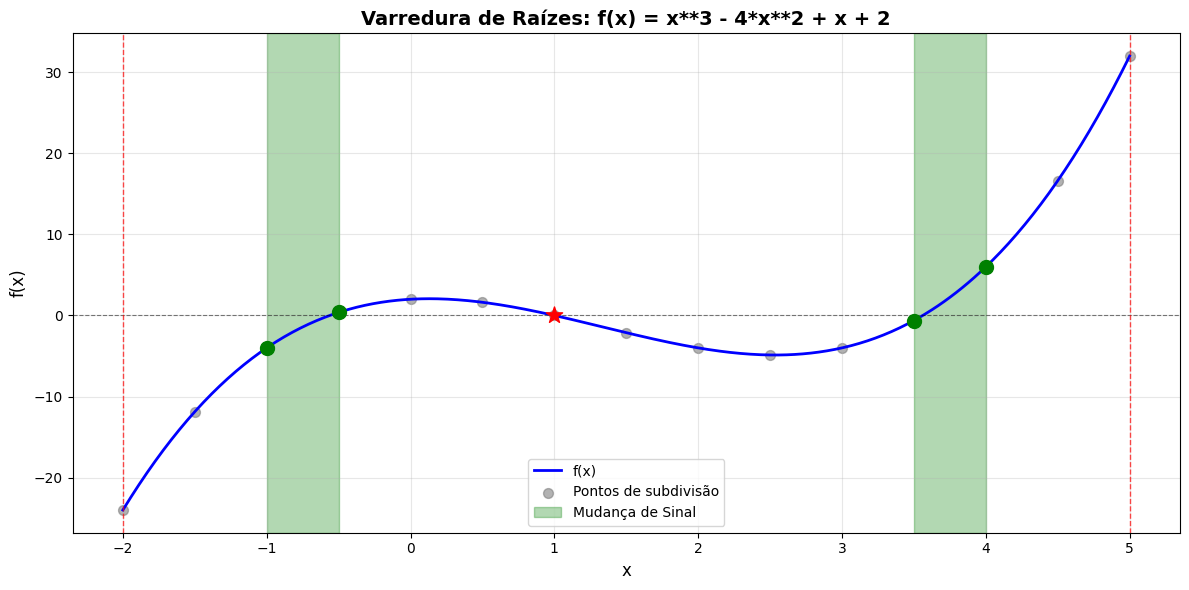


5. REFINAMENTO E PRÓXIMOS PASSOS
------------------------------------------------------------

Opções:
1. Refinar a busca com um novo valor de N
2. Prosseguir para o cálculo de raízes (Método da Bisseção)
3. Sair

Próxima etapa: Execute a próxima célula para calcular raízes com o método da bisseção.
Intervalos disponíveis para cálculo guardados na memória.


'\n# Cenário 1: Polinômio com múltiplas raízes\nx**3 - 4*x**2 + x + 2\n-2\n5\n14\n\n# Cenário 2: Função Trigonométrica\nsin(x) - 0.5\n0\n6\n12\n\n# Cenário 3: Teste de "Zero Exato"\nx**2 - 4\n0\n4\n4\n'

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, sympify
import pandas as pd

def busca_incremental_raizes():
    """
    Implementa a busca incremental de possíveis raízes num intervalo.
    Baseado na seção 5.4, página 113.
    Retorna uma tupla: (lista_de_intervalos_detectados, expressao_em_string)
    """
    print("="*60)
    print("MÉTODO 1: VARREDURA DE POSSÍVEIS RAÍZES")
    print("="*60)
    
    # Etapa 1: Receber entrada do usuário
    print("\n1. ENTRADA DE DADOS")
    print("-" * 60)
    
    expr_str = input("Insira a expressão da função f(x): ").strip()
    intervalo_1 = float(input("Insira a primeira extremidade do intervalo: "))
    intervalo_2 = float(input("Insira a segunda extremidade do intervalo: "))
    N = int(input("Insira o número N de subdivisões: "))
    
    # Validar intervalo
    if intervalo_1 > intervalo_2:
        intervalo_1, intervalo_2 = intervalo_2, intervalo_1
    
    # Converter string para função
    x = symbols('x')
    try:
        expr = sympify(expr_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return None, None
    
    # Etapa 2: Calcular pontos de subdivisão
    print("\n2. CÁLCULO DAS SUBDIVISÕES")
    print("-" * 60)
    
    pontos = np.linspace(intervalo_1, intervalo_2, N + 1)
    valores_funcao = f(pontos)
    
    # Criar tabela de subdivisões
    dados_subdivisoes = pd.DataFrame({
        'Ponto': pontos,
        'f(x)': valores_funcao,
        'Sinal': ['Positivo' if v > 0 else 'Negativo' if v < 0 else 'Zero' for v in valores_funcao]
    })
    
    print("\nTabela de Subdivisões:")
    print(dados_subdivisoes.to_string(index=False))
    
    # Etapa 3: Detectar mudanças de sinal
    print("\n3. DETECÇÃO DE MUDANÇAS DE SINAL")
    print("-" * 60)
    
    subintervalos_raizes = []
    
    for i in range(len(pontos) - 1):
        if valores_funcao[i] * valores_funcao[i+1] < 0:
            subintervalos_raizes.append({
                'Inicio': pontos[i],
                'Fim': pontos[i+1],
                'f(inicio)': valores_funcao[i],
                'f(fim)': valores_funcao[i+1],
                'Tipo': 'Mudança de Sinal'
            })
        elif valores_funcao[i] == 0:
            subintervalos_raizes.append({
                'Inicio': pontos[i],
                'Fim': pontos[i],
                'f(inicio)': valores_funcao[i],
                'f(fim)': valores_funcao[i],
                'Tipo': 'Zero Encontrado'
            })
    
    if valores_funcao[-1] == 0:
        subintervalos_raizes.append({
            'Inicio': pontos[-1],
            'Fim': pontos[-1],
            'f(inicio)': valores_funcao[-1],
            'f(fim)': valores_funcao[-1],
            'Tipo': 'Zero Encontrado'
        })
    
    print(f"\nTotal de possíveis raízes detectadas: {len(subintervalos_raizes)}")
    
    if subintervalos_raizes:
        df_raizes = pd.DataFrame(subintervalos_raizes)
        print("\nSubintervalos com possíveis raízes:")
        print(df_raizes.to_string(index=False))
    else:
        print("Nenhuma raiz detectada neste intervalo!")
    
    # Etapa 4: Plotar gráfico
    print("\n4. VISUALIZAÇÃO GRÁFICA")
    print("-" * 60)
    
    x_plot = np.linspace(intervalo_1, intervalo_2, 500)
    y_plot = f(x_plot)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
    ax.scatter(pontos, valores_funcao, color='gray', s=50, alpha=0.6, label='Pontos de subdivisão')
    
    for raiz in subintervalos_raizes:
        if raiz['Tipo'] == 'Mudança de Sinal':
            ax.axvspan(raiz['Inicio'], raiz['Fim'], alpha=0.3, color='green', label='Mudança de Sinal' if raiz == subintervalos_raizes[0] else '')
            ax.scatter([raiz['Inicio'], raiz['Fim']], [raiz['f(inicio)'], raiz['f(fim)']], 
                      color='green', s=100, marker='o', zorder=5)
        elif raiz['Tipo'] == 'Zero Encontrado':
            ax.scatter([raiz['Inicio']], [raiz['f(inicio)']], 
                      color='red', s=150, marker='*', zorder=5, label='Zero Encontrado' if raiz == subintervalos_raizes[0] else '')
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=intervalo_1, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=intervalo_2, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.set_title(f'Varredura de Raízes: f(x) = {expr_str}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    
    # Etapa 5: Oferecer opções de refinamento
    print("\n5. REFINAMENTO E PRÓXIMOS PASSOS")
    print("-" * 60)
    print("\nOpções:")
    print("1. Refinar a busca com um novo valor de N")
    print("2. Prosseguir para o cálculo de raízes (Método da Bisseção)")
    print("3. Sair")
    
    opcao = input("\nEscolha uma opção (1, 2 ou 3): ").strip()
    
    if opcao == '1':
        print("\nRetornando para refinar a busca...")
        return busca_incremental_raizes()
    elif opcao == '2':
        print("\nPróxima etapa: Execute a próxima célula para calcular raízes com o método da bisseção.")
        if subintervalos_raizes:
            print("Intervalos disponíveis para cálculo guardados na memória.")
        return subintervalos_raizes, expr_str
    else:
        print("\nSaída do programa.")
        return None, None

# Executar o programa e salvar as variáveis globalmente
# Desempacotar a tupla gerada na opção 2.
try:
    resultado_varredura, expressao_funcao = busca_incremental_raizes()
except ValueError:
    pass # Tratamento para caso ocorra interrupção inexperada

'''
# Cenário 1: Polinômio com múltiplas raízes
x**3 - 4*x**2 + x + 2
-2
5
14

# Cenário 2: Função Trigonométrica
sin(x) - 0.5
0
6
12

# Cenário 3: Teste de "Zero Exato"
x**2 - 4
0
4
4
'''

### 2. Método da Bisseção
* Implementar rotina para calcular as raízes detectadas na varredura via método da bisseção.
* Receber do usuário o nível de precisão (tolerância).
* Mostrar tabela com resultados de todas as iterações.
* A tabela deve conter: número da iteração, valor da esquerda, valor da direita, ponto médio e valor da função no ponto médio.
* Solicitar ao usuário se deseja repetir o processo para a próxima raiz, caso mais de uma tenha sido detectada.

In [ ]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify

def metodo_bisseccao(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da bisseção para encontrar raízes.
    
    Parâmetros:
    - f: função
    - a, b: extremidades do intervalo
    - tolerancia: critério de convergência
    - max_iteracoes: número máximo de iterações
    
    Retorna:
    - DataFrame com histórico de iterações
    - raiz aproximada
    """
    
    # Validar intervalo
    if f(a) * f(b) > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    
    # Garantir que a < b
    if a > b:
        a, b = b, a
    
    while (b - a) > tolerancia and iteracao < max_iteracoes:
        c = (a + b) / 2  # Ponto médio
        fc = f(c)
        
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Ponto Médio)': c,
            'f(c)': fc,
            'Erro Absoluto': (b - a) / 2
        })
        
        # Atualizar intervalo baseado no sinal
        if f(a) * fc < 0:
            b = c  # Raiz está em [a, c]
        else:
            a = c  # Raiz está em [c, b]
        
        iteracao += 1
    
    # Último ponto
    c = (a + b) / 2
    fc = f(c)
    iteracoes.append({
        'Iteração': iteracao + 1,
        'a (Esquerda)': a,
        'b (Direita)': b,
        'c (Ponto Médio)': c,
        'f(c)': fc,
        'Erro Absoluto': (b - a) / 2
    })
    
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c

def executor_bisseccao(subintervalos_raizes, f_str):
    """
    Executa o método da bisseção para todos os intervalos detectados.
    """
    if not subintervalos_raizes:
        print("\nNenhum intervalo com raiz disponível!")
        return
    
    print("\n" + "="*80)
    print("MÉTODO 2: MÉTODO DA BISSEÇÃO")
    print("="*80)
    
    # Receber tolerância do usuário
    print("\nInserção de Parâmetro:")
    print("-" * 80)
    try:
        tolerancia = float(input("Insira a tolerância (precisão) desejada: "))
        if tolerancia <= 0:
            print("Erro: Tolerância deve ser positiva!")
            return
    except:
        print("Erro: Valor inválido para tolerância!")
        return
    
    # Converter string para função
    x = symbols('x')
    try:
        expr = sympify(f_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return
    
    resultados_totais = []
    
    for idx, intervalo in enumerate(subintervalos_raizes, 1):
        print(f"\n{'='*80}")
        print(f"Raiz #{idx} - Intervalo: [{intervalo['Inicio']:.6f}, {intervalo['Fim']:.6f}]")
        print(f"{'='*80}")
        
        a = intervalo['Inicio']
        b = intervalo['Fim']
        
        # Executar bisseção
        df_resultado, raiz_aprox = metodo_bisseccao(f, a, b, tolerancia)
        
        if df_resultado is not None and len(df_resultado) > 0:
            print(f"\nTabela de Iterações:")
            print(df_resultado.to_string(index=False))
            
            print(f"\n{'─'*80}")
            print(f"Resultado Final:")
            print(f"  Raiz Aproximada: {raiz_aprox:.10f}")
            print(f"  f(raiz): {f(raiz_aprox):.2e}")
            print(f"  Número de Iterações: {len(df_resultado) - 1}")
            print(f"  Erro Absoluto Final: {df_resultado['Erro Absoluto'].iloc[-1]:.2e}")
            print(f"{'─'*80}")
            
            resultados_totais.append({
                'Raiz #': idx,
                'Raiz Aproximada': raiz_aprox,
                'f(raiz)': f(raiz_aprox),
                'Iterações': len(df_resultado) - 1,
                'Tolerância': tolerancia
            })
            
            # Perguntar se deseja continuar para próxima raiz
            if idx < len(subintervalos_raizes):
                continuar = input("\nDeseja continuar para a próxima raiz? (s/n): ").strip().lower()
                if continuar != 's':
                    print("\nExecução interrompida pelo usuário.")
                    break
        else:
            print(f"Não foi possível calcular a raiz neste intervalo.")
    
    # Resumo final
    if resultados_totais:
        print(f"\n{'='*80}")
        print("RESUMO DE TODAS AS RAÍZES CALCULADAS")
        print(f"{'='*80}")
        df_resumo = pd.DataFrame(resultados_totais)
        print(df_resumo.to_string(index=False))
        print(f"{'='*80}\n")
    
    return resultados_totais

# =====================================================================
# EXECUÇÃO PROCEDURAL DO MÉTODO DA BISSEÇÃO
# =====================================================================
# Verifica se a varredura foi executada e as variáveis estão salvas na memória do Notebook
if 'resultado_varredura' in locals() and resultado_varredura is not None:
    resultados_bisseccao = executor_bisseccao(resultado_varredura, expressao_funcao)
else:
    print("Aviso: Variáveis globais da varredura não encontradas.")
    print("Por favor, suba e execute a célula '1. Varredura de possíveis raízes' PRIMEIRO.")



MÉTODO 2: MÉTODO DA BISSEÇÃO

Inserção de Parâmetro:
--------------------------------------------------------------------------------

Raiz #1 - Intervalo: [-1.000000, -0.500000]

Tabela de Iterações:
 Iteração  a (Esquerda)  b (Direita)  c (Ponto Médio)      f(c)  Erro Absoluto
        1     -1.000000    -0.500000        -0.750000 -1.421875   2.500000e-01
        2     -0.750000    -0.500000        -0.625000 -0.431641   1.250000e-01
        3     -0.625000    -0.500000        -0.562500 -0.006104   6.250000e-02
        4     -0.562500    -0.500000        -0.531250  0.189911   3.125000e-02
        5     -0.562500    -0.531250        -0.546875  0.093281   1.562500e-02
        6     -0.562500    -0.546875        -0.554688  0.043934   7.812500e-03
        7     -0.562500    -0.554688        -0.558594  0.019002   3.906250e-03
        8     -0.562500    -0.558594        -0.560547  0.006471   1.953125e-03
        9     -0.562500    -0.560547        -0.561523  0.000189   9.765625e-04
       1

### 3. Método da Falsa posição
* Implementar rotina semelhante à da bisseção, aplicando o método da falsa posição.

In [ ]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify

def metodo_falsa_posicao(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da falsa posição para encontrar raízes.
    
    Parâmetros:
    - f: função
    - a, b: extremidades do intervalo
    - tolerancia: critério de convergência (baseado na variação de c)
    - max_iteracoes: número máximo de iterações
    
    Retorna:
    - DataFrame com histórico de iterações
    - raiz aproximada
    """
    
    # Validar se existe raiz no intervalo
    if f(a) * f(b) > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    c_old = a
    erro = abs(b - a)
    
    # Na falsa posição um dos limites pode permanecer estático. 
    # Usamos o erro absoluto focado na mudança de 'c' entre as iterações.
    while erro > tolerancia and iteracao < max_iteracoes:
        fa = f(a)
        fb = f(b)
        
        # Evitar divisão por zero na fórmula
        if fb - fa == 0:
            print("Erro: Divisão por zero na fórmula da Falsa Posição.")
            break
            
        # Fórmula da Falsa Posição
        c = (a * fb - b * fa) / (fb - fa)
        fc = f(c)
        
        # O erro absoluto a partir da 2ª iteração é a diferença entre o c atual e o anterior
        if iteracao > 0:
            erro = abs(c - c_old)
            
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Falsa Posição)': c,
            'f(c)': fc,
            'Erro Absoluto': erro
        })
        
        # Atualizar intervalo baseado no sinal
        if fa * fc < 0:
            b = c  # Raiz está em [a, c]
        else:
            a = c  # Raiz está em [c, b]
            
        c_old = c
        iteracao += 1
        
        # Condição de parada de segurança caso chegue à raiz exata
        if abs(fc) < 1e-15:
            break
            
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c_old

def executor_falsa_posicao(subintervalos_raizes, f_str):
    """
    Executa o método da falsa posição iterando por todos os intervalos detectados.
    """
    if not subintervalos_raizes:
        print("\nNenhum intervalo com raiz disponível!")
        return
    
    print("\n" + "="*80)
    print("MÉTODO 3: MÉTODO DA FALSA POSIÇÃO")
    print("="*80)
    
    # Receber tolerância do usuário (Requisito 2.2 / 3.1)
    print("\nInserção de Parâmetro:")
    print("-" * 80)
    try:
        tolerancia = float(input("Insira o nível de precisão (tolerância) desejado: "))
        if tolerancia <= 0:
            print("Erro: Tolerância deve ser positiva!")
            return
    except:
        print("Erro: Valor numérico inválido para tolerância!")
        return
    
    # Converter string para função utilizando SymPy
    x = symbols('x')
    try:
        expr = sympify(f_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return
    
    resultados_totais = []
    
    for idx, intervalo in enumerate(subintervalos_raizes, 1):
        print(f"\n{'='*80}")
        print(f"Raiz #{idx} - Intervalo: [{intervalo['Inicio']:.6f}, {intervalo['Fim']:.6f}]")
        print(f"{'='*80}")
        
        a = intervalo['Inicio']
        b = intervalo['Fim']
        
        # Executar falsa posição
        df_resultado, raiz_aprox = metodo_falsa_posicao(f, a, b, tolerancia)
        
        if df_resultado is not None and len(df_resultado) > 0:
            # Exibir Tabela (Requisito 2.3 / 3.1)
            print(f"\nTabela de Iterações:")
            print(df_resultado.to_string(index=False))
            
            print(f"\n{'─'*80}")
            print(f"Resultado Final:")
            print(f"  Raiz Aproximada: {raiz_aprox:.10f}")
            print(f"  f(raiz): {f(raiz_aprox):.2e}")
            print(f"  Número de Iterações: {len(df_resultado)}")
            print(f"  Erro Absoluto Final: {df_resultado['Erro Absoluto'].iloc[-1]:.2e}")
            print(f"{'─'*80}")
            
            resultados_totais.append({
                'Raiz #': idx,
                'Raiz Aproximada': raiz_aprox,
                'f(raiz)': f(raiz_aprox),
                'Iterações': len(df_resultado),
                'Tolerância': tolerancia
            })
            
            # Solicitar continuação caso haja mais raízes detectadas (Requisito 2.3 / 3.1)
            if idx < len(subintervalos_raizes):
                continuar = input("\nDeseja repetir o processo para a próxima raiz? (s/n): ").strip().lower()
                if continuar != 's':
                    print("\nExecução interrompida pelo usuário.")
                    break
        else:
            print(f"Não foi possível calcular a raiz neste intervalo.")
    
    # Resumo final
    if resultados_totais:
        print(f"\n{'='*80}")
        print("RESUMO DE TODAS AS RAÍZES CALCULADAS (FALSA POSIÇÃO)")
        print(f"{'='*80}")
        df_resumo = pd.DataFrame(resultados_totais)
        print(df_resumo.to_string(index=False))
        print(f"{'='*80}\n")
    
    return resultados_totais

# =====================================================================
# EXECUÇÃO PROCEDURAL DO MÉTODO DA FALSA POSIÇÃO
# =====================================================================
# Verifica se a varredura foi executada e as variáveis estão salvas na memória do Notebook
if 'resultado_varredura' in locals() and resultado_varredura is not None:
    resultados_falsa_posicao = executor_falsa_posicao(resultado_varredura, expressao_funcao)
else:
    print("Aviso: Variáveis globais da varredura não encontradas.")
    print("Por favor, suba e execute a célula '1. Varredura de possíveis raízes' PRIMEIRO.")



MÉTODO 3: MÉTODO DA FALSA POSIÇÃO

Inserção de Parâmetro:
--------------------------------------------------------------------------------

Raiz #1 - Intervalo: [-1.000000, -0.500000]

Tabela de Iterações:
 Iteração  a (Esquerda)  b (Direita)  c (Falsa Posição)     f(c)  Erro Absoluto
        1          -1.0    -0.500000          -0.542857 0.118391       0.500000
        2          -1.0    -0.542857          -0.555999 0.035586       0.013141
        3          -1.0    -0.555999          -0.559914 0.010538       0.003915
        4          -1.0    -0.559914          -0.561070 0.003107       0.001156
        5          -1.0    -0.561070          -0.561411 0.000915       0.000341

────────────────────────────────────────────────────────────────────────────────
Resultado Final:
  Raiz Aproximada: -0.5614107240
  f(raiz): 9.15e-04
  Número de Iterações: 5
  Erro Absoluto Final: 3.41e-04
────────────────────────────────────────────────────────────────────────────────

Raiz #2 - Intervalo: [

### 4. Comparação entre os métodos
* Implementar comparação gráfica entre bisseção e falsa posição.
* Mostrar graficamente que o método da falsa posição converge mais rápido, semelhante à figura 5.13 da página 110.


RAIZ 1 — intervalo [-1.0000, -0.5000]
Raiz verdadeira (referência): -0.5615528128

--- BISSEÇÃO ---

 Iteração  a (Esquerda)  b (Direita)  c (Ponto Médio)      f(c)  Erro Absoluto
        1     -1.000000    -0.500000        -0.750000 -1.421875       0.250000
        2     -0.750000    -0.500000        -0.625000 -0.431641       0.125000
        3     -0.625000    -0.500000        -0.562500 -0.006104       0.062500
        4     -0.562500    -0.500000        -0.531250  0.189911       0.031250
        5     -0.562500    -0.531250        -0.546875  0.093281       0.015625
        6     -0.562500    -0.546875        -0.554688  0.043934       0.007812
        7     -0.562500    -0.554688        -0.558594  0.019002       0.003906
        8     -0.562500    -0.558594        -0.560547  0.006471       0.001953
        9     -0.562500    -0.560547        -0.561523  0.000189       0.000977
       10     -0.562500    -0.561523        -0.562012 -0.002956       0.000488
       11     -0.562012    -0

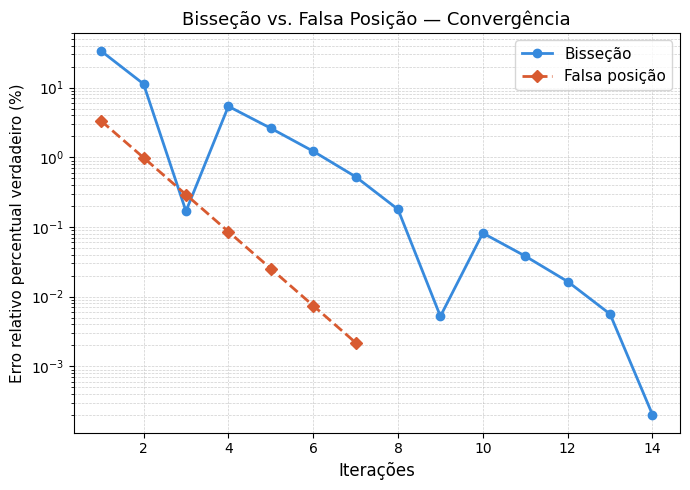


RAIZ 2 — intervalo [3.5000, 4.0000]
Raiz verdadeira (referência): 3.5615528128

--- BISSEÇÃO ---

 Iteração  a (Esquerda)  b (Direita)  c (Ponto Médio)      f(c)  Erro Absoluto
        1      3.500000     4.000000         3.750000  2.234375       0.250000
        2      3.500000     3.750000         3.625000  0.697266       0.125000
        3      3.500000     3.625000         3.562500  0.010010       0.062500
        4      3.500000     3.562500         3.531250 -0.313934       0.031250
        5      3.531250     3.562500         3.546875 -0.153584       0.015625
        6      3.546875     3.562500         3.554688 -0.072194       0.007812
        7      3.554688     3.562500         3.558594 -0.031194       0.003906
        8      3.558594     3.562500         3.560547 -0.010618       0.001953
        9      3.560547     3.562500         3.561523 -0.000310       0.000977
       10      3.561523     3.562500         3.562012  0.004848       0.000488
       11      3.561523     3.56

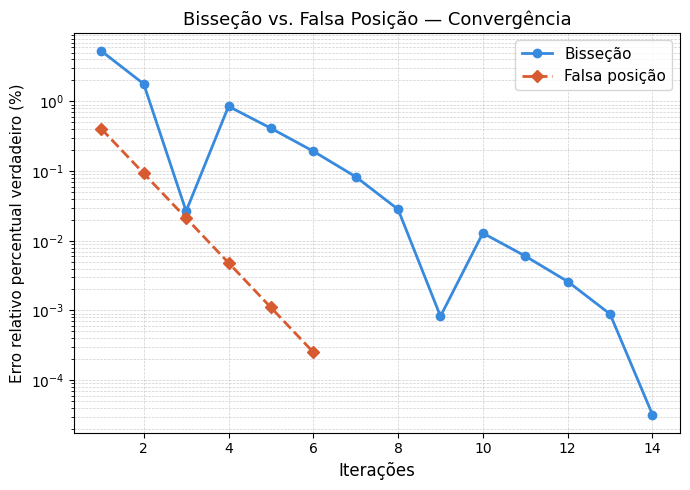


Fim do programa!


In [8]:
# Raiz verdadeira (referência para calcular erro percentual)

def raiz_verdadeira(f, a, b, tol=1e-12):
    for _ in range(200):
        mid = (a + b) / 2
        if f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
        if (b - a) < tol:
            break
    return (a + b) / 2

# Parte 1: Método da Falsa Posição

def metodo_falsa_posicao(f, xl, xu, tol, raiz):
    resultados = []
    iteracoes_df = []
    c_old = xl
    erro_parada = abs(xu - xl)
    iteracao = 1
    max_iter = 100

    while erro_parada > tol and iteracao <= max_iter:
        fa = f(xl)
        fb = f(xu)

        if fb - fa == 0:
            print("Erro: Divisão por zero na fórmula.")
            break

        # Fórmula da Falsa Posição
        c = (xl * fb - xu * fa) / (fb - fa)
        fc = f(c)

        # Erro de parada: variação de c entre iterações
        if iteracao > 1:
            erro_parada = abs(c - c_old)

        # Erro verdadeiro percentual (para o gráfico comparativo)
        erro_verdadeiro = abs((c - raiz) / raiz) * 100 if raiz != 0 else abs(c - raiz)

        iteracoes_df.append({
            'Iter':      iteracao,
            'xl':        xl,
            'xu':        xu,
            'xr':        c,
            'f(xr)':     fc,
            'Erro Abs':  erro_parada
        })

        resultados.append((iteracao, c, erro_verdadeiro))

        # Atualização do intervalo
        if fa * fc < 0:
            xu = c
        else:
            xl = c

        c_old = c
        iteracao += 1

        if abs(fc) < 1e-15:
            break

    # Exibe tabela com pandas
    df = pd.DataFrame(iteracoes_df)
    print("\n" + df.to_string(index=False))
    print(f"\n=> Raiz encontrada: {c_old:.10f} com {iteracao-1} iterações.")

    return resultados      

# Parte 2: Método da Bisseção

def metodo_bisseccao(f, a, b, tolerancia, max_iteracoes=100):
    if f(a) * f(b) > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    if a > b:
        a, b = b, a

    iteracoes = []
    iteracao = 0

    while (b - a) > tolerancia and iteracao < max_iteracoes:
        c = (a + b) / 2
        fc = f(c)
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Ponto Médio)': c,
            'f(c)': fc,
            'Erro Absoluto': (b - a) / 2
        })
        if f(a) * fc < 0:
            b = c
        else:
            a = c
        iteracao += 1

    c = (a + b) / 2
    iteracoes.append({
        'Iteração': iteracao + 1,
        'a (Esquerda)': a,
        'b (Direita)': b,
        'c (Ponto Médio)': c,
        'f(c)': f(c),
        'Erro Absoluto': (b - a) / 2
    })

    df = pd.DataFrame(iteracoes)
    print("\n" + df.to_string(index=False))
    return df, c

def metodo_bissecao(f, xl, xu, tol, raiz):
    """Adaptador: chama metodo_bisseccao e converte para o formato do plotar_comparacao."""
    df, _ = metodo_bisseccao(f, xl, xu, tol)
    if df is None:
        return []
    resultados = []
    for _, row in df.iterrows():
        c = row['c (Ponto Médio)']
        erro = abs((c - raiz) / raiz) * 100 if raiz != 0 else abs(c - raiz)
        resultados.append((int(row['Iteração']), c, erro))
    return resultados


# ── Gráfico comparativo ────────────────────────────────────────────────────
def plotar_comparacao(res_bis, res_fp):
    iters_b = [r[0] for r in res_bis]
    erros_b = [r[2] for r in res_bis]
    iters_f = [r[0] for r in res_fp]
    erros_f = [r[2] for r in res_fp]

    print(f"\n{'Iter':>4} │ {'Bisseção xr':>14} {'Erro (%)':>12} │ {'Falsa Pos. xr':>14} {'Erro (%)':>12}")
    print("─" * 65)
    for i in range(max(len(res_bis), len(res_fp))):
        b = res_bis[i] if i < len(res_bis) else (i+1, float('nan'), float('nan'))
        fp = res_fp[i] if i < len(res_fp) else (i+1, float('nan'), float('nan'))
        print(f"{b[0]:>4} │ {b[1]:>14.8f} {b[2]:>12.4e} │ {fp[1]:>14.8f} {fp[2]:>12.4e}")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.semilogy(iters_b, erros_b, 'o-',  color='#378ADD', lw=2, ms=6, label='Bisseção')
    ax.semilogy(iters_f, erros_f, 'D--', color='#D85A30', lw=2, ms=6, label='Falsa posição')
    ax.set_xlabel('Iterações', fontsize=12)
    ax.set_ylabel('Erro relativo percentual verdadeiro (%)', fontsize=11)
    ax.set_title('Bisseção vs. Falsa Posição — Convergência', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
    plt.tight_layout()
    plt.savefig('convergencia.png', dpi=150)
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# EXECUÇÃO PRINCIPAL
# ══════════════════════════════════════════════════════════════════════════════

# Converte os resultados da nova varredura para o formato esperado
if resultado_varredura is None:
    print("Nenhum intervalo encontrado. Encerrando.")
else:
    # Recria a função a partir da string (nova varredura usa sympy)
    from sympy import symbols, lambdify, sympify
    x_sym = symbols('x')
    funcao = lambdify(x_sym, sympify(expressao_funcao), 'numpy')

    # Converte dicionários → tuplas
    subintervalos = [
        (iv['Inicio'], iv['Fim'])
        for iv in resultado_varredura
        if iv['Tipo'] == 'Mudança de Sinal'
    ]

    tol = float(input("\nForneça a tolerância desejada (ex: 1e-4): "))

    for idx, (xl, xu) in enumerate(subintervalos):
        print(f"\n{'='*50}")
        print(f"RAIZ {idx+1} — intervalo [{xl:.4f}, {xu:.4f}]")
        print(f"{'='*50}")

        raiz = raiz_verdadeira(funcao, xl, xu)
        print(f"Raiz verdadeira (referência): {raiz:.10f}")

        print("\n--- BISSEÇÃO ---")
        res_bis = metodo_bissecao(funcao, xl, xu, tol, raiz)

        print("\n--- FALSA POSIÇÃO ---")
        res_fp = metodo_falsa_posicao(funcao, xl, xu, tol, raiz)

        plotar_comparacao(res_bis, res_fp)

        if idx < len(subintervalos) - 1:
            prosseguir = input("\nDeseja calcular a PRÓXIMA raiz? (s/n): ").strip().lower()
            if prosseguir != 's':
                print("Processo abortado.")
                break

print("\nFim do programa!")

### 5. Método da Falsa posição modificado
* Implementar rotina aplicando o método da falsa posição modificado, conforme página 112.

In [13]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify

def metodo_falsa_posicao_modificada(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da falsa posição modificado para encontrar raízes.
    Evita o problema da "extremidade presa" dividindo f(x) por 2 na extremidade estagnada.
    """
    fa = f(a)
    fb = f(b)
    
    # Validar se existe raiz no intervalo
    if fa * fb > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    c_old = a
    erro = abs(b - a)
    
    il = 0  # Contador de estagnação para o limite inferior (a)
    iu = 0  # Contador de estagnação para o limite superior (b)
    
    while erro > tolerancia and iteracao < max_iteracoes:
        # Evitar divisão por zero na fórmula
        if fb - fa == 0:
            print("Erro: Divisão por zero na fórmula da Falsa Posição Modificada.")
            break
            
        # Fórmula da Falsa Posição (xr = xu - fu * (xl - xu) / (fl - fu))
        c = b - fb * (a - b) / (fa - fb)
        fc = f(c)
        
        # O erro absoluto a partir da 2ª iteração é a diferença entre o c atual e o anterior
        if iteracao > 0:
            erro = abs(c - c_old)
            
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Falsa Pos. Mod)': c,
            'f(c)': fc,
            'Erro Absoluto': erro
        })
        
        test = fa * fc
        
        # Lógica de atualização com detecção de extremidade presa
        if test < 0:
            # Raiz está no subintervalo inferior [a, c]
            b = c
            fb = f(b)
            iu = 0
            il += 1
            if il >= 2:
                fa = fa / 2
        elif test > 0:
            # Raiz está no subintervalo superior [c, b]
            a = c
            fa = f(a)
            il = 0
            iu += 1
            if iu >= 2:
                fb = fb / 2
        else:
            # Raiz exata encontrada
            erro = 0
            
        c_old = c
        iteracao += 1
        
        # Condição de parada de segurança
        if abs(fc) < 1e-15:
            break
            
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c_old

def executor_falsa_posicao_modificada(subintervalos_raizes, f_str):
    """
    Executa o método da falsa posição modificada iterando por todos os intervalos detectados.
    """
    if not subintervalos_raizes:
        print("\nNenhum intervalo com raiz disponível!")
        return
    
    print("\n" + "="*80)
    print("MÉTODO 5: MÉTODO DA FALSA POSIÇÃO MODIFICADO")
    print("="*80)
    
    print("\nInserção de Parâmetro:")
    print("-" * 80)
    try:
        tolerancia = float(input("Insira o nível de precisão (tolerância) desejado: "))
        if tolerancia <= 0:
            print("Erro: Tolerância deve ser positiva!")
            return
    except:
        print("Erro: Valor numérico inválido para tolerância!")
        return
    
    # Converter string para função utilizando SymPy
    x = symbols('x')
    try:
        expr = sympify(f_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return
    
    resultados_totais = []
    
    for idx, intervalo in enumerate(subintervalos_raizes, 1):
        print(f"\n{'='*80}")
        print(f"Raiz #{idx} - Intervalo: [{intervalo['Inicio']:.6f}, {intervalo['Fim']:.6f}]")
        print(f"{'='*80}")
        
        a = intervalo['Inicio']
        b = intervalo['Fim']
        
        # Executar falsa posição modificada
        df_resultado, raiz_aprox = metodo_falsa_posicao_modificada(f, a, b, tolerancia)
        
        if df_resultado is not None and len(df_resultado) > 0:
            print(f"\nTabela de Iterações:")
            print(df_resultado.to_string(index=False))
            
            print(f"\n{'─'*80}")
            print(f"Resultado Final:")
            print(f"  Raiz Aproximada: {raiz_aprox:.10f}")
            print(f"  f(raiz): {f(raiz_aprox):.2e}")
            print(f"  Número de Iterações: {len(df_resultado)}")
            print(f"  Erro Absoluto Final: {df_resultado['Erro Absoluto'].iloc[-1]:.2e}")
            print(f"{'─'*80}")
            
            resultados_totais.append({
                'Raiz #': idx,
                'Raiz Aproximada': raiz_aprox,
                'f(raiz)': f(raiz_aprox),
                'Iterações': len(df_resultado),
                'Tolerância': tolerancia
            })
            
            if idx < len(subintervalos_raizes):
                continuar = input("\nDeseja repetir o processo para a próxima raiz? (s/n): ").strip().lower()
                if continuar != 's':
                    print("\nExecução interrompida pelo usuário.")
                    break
        else:
            print(f"Não foi possível calcular a raiz neste intervalo.")
    
    if resultados_totais:
        print(f"\n{'='*80}")
        print("RESUMO DE TODAS AS RAÍZES CALCULADAS (FALSA POSIÇÃO MODIFICADA)")
        print(f"{'='*80}")
        df_resumo = pd.DataFrame(resultados_totais)
        print(df_resumo.to_string(index=False))
        print(f"{'='*80}\n")
    
    return resultados_totais

# =====================================================================
# EXECUÇÃO PROCEDURAL DO MÉTODO
# =====================================================================
# Verifica se a varredura foi executada e as variáveis estão salvas na memória do Notebook
if 'resultado_varredura' in locals() and resultado_varredura is not None:
    resultados_falsa_posicao_modificada = executor_falsa_posicao_modificada(resultado_varredura, expressao_funcao)
else:
    print("Aviso: Variáveis globais da varredura não encontradas.")
    print("Por favor, suba e execute a célula '1. Varredura de possíveis raízes' PRIMEIRO.")



MÉTODO 5: MÉTODO DA FALSA POSIÇÃO MODIFICADO

Inserção de Parâmetro:
--------------------------------------------------------------------------------

Raiz #1 - Intervalo: [-1.000000, -0.500000]

Tabela de Iterações:
 Iteração  a (Esquerda)  b (Direita)  c (Falsa Pos. Mod)      f(c)  Erro Absoluto
        1          -1.0    -0.500000           -0.542857  0.118391       0.500000
        2          -1.0    -0.542857           -0.555999  0.035586       0.013141
        3          -1.0    -0.555999           -0.563760 -0.014242       0.007762

────────────────────────────────────────────────────────────────────────────────
Resultado Final:
  Raiz Aproximada: -0.5637604787
  f(raiz): -1.42e-02
  Número de Iterações: 3
  Erro Absoluto Final: 7.76e-03
────────────────────────────────────────────────────────────────────────────────

Raiz #2 - Intervalo: [1.000000, 1.000000]
Não foi possível calcular a raiz neste intervalo.

Raiz #3 - Intervalo: [3.500000, 4.000000]

Tabela de Iterações:
 Iter

### 6. Integração entre os métodos
* Implementar rotina que recebe intervalos de interesse da varredura.
* Calcular raízes usando bisseção, falsa posição e falsa posição modificado.
* Construir uma tabela por raiz por método com todas as iterações.
* Imprimir mensagem informando qual método precisou de menos iterações para cada raiz.

In [16]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify

# Parte 1: Método da Bisseção

def metodo_bisseccao(f, a, b, tolerancia, max_iteracoes=100):
    
    # Validar intervalo
    if f(a) * f(b) > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    
    # Garantir que a < b
    if a > b:
        a, b = b, a
    
    while (b - a) > tolerancia and iteracao < max_iteracoes:
        c = (a + b) / 2  # Ponto médio
        fc = f(c)
        
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Ponto Médio)': c,
            'f(c)': fc,
            'Erro Absoluto': (b - a) / 2
        })
        
        # Atualizar intervalo baseado no sinal
        if f(a) * fc < 0:
            b = c  # Raiz está em [a, c]
        else:
            a = c  # Raiz está em [c, b]
        
        iteracao += 1
    
    # Último ponto
    c = (a + b) / 2
    fc = f(c)
    iteracoes.append({
        'Iteração': iteracao + 1,
        'a (Esquerda)': a,
        'b (Direita)': b,
        'c (Ponto Médio)': c,
        'f(c)': fc,
        'Erro Absoluto': (b - a) / 2
    })
    
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c

# Parte 2: Método da Falsa Posição

def metodo_falsa_posicao(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da falsa posição para encontrar raízes.
    
    Parâmetros:
    - f: função
    - a, b: extremidades do intervalo
    - tolerancia: critério de convergência (baseado na variação de c)
    - max_iteracoes: número máximo de iterações
    
    Retorna:
    - DataFrame com histórico de iterações
    - raiz aproximada
    """
    
    # Validar se existe raiz no intervalo
    if f(a) * f(b) > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    c_old = a
    erro = abs(b - a)
    
    # Na falsa posição um dos limites pode permanecer estático. 
    # Usamos o erro absoluto focado na mudança de 'c' entre as iterações.
    while erro > tolerancia and iteracao < max_iteracoes:
        fa = f(a)
        fb = f(b)
        
        # Evitar divisão por zero na fórmula
        if fb - fa == 0:
            print("Erro: Divisão por zero na fórmula da Falsa Posição.")
            break
            
        # Fórmula da Falsa Posição
        c = (a * fb - b * fa) / (fb - fa)
        fc = f(c)
        
        # O erro absoluto a partir da 2ª iteração é a diferença entre o c atual e o anterior
        if iteracao > 0:
            erro = abs(c - c_old)
            
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Falsa Posição)': c,
            'f(c)': fc,
            'Erro Absoluto': erro
        })
        
        # Atualizar intervalo baseado no sinal
        if fa * fc < 0:
            b = c  # Raiz está em [a, c]
        else:
            a = c  # Raiz está em [c, b]
            
        c_old = c
        iteracao += 1
        
        # Condição de parada de segurança caso chegue à raiz exata
        if abs(fc) < 1e-15:
            break
            
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c_old

# Parte 3: Método da Falsa Posição Modificada

def metodo_falsa_posicao_modificada(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da falsa posição modificado para encontrar raízes.
    Evita o problema da "extremidade presa" dividindo f(x) por 2 na extremidade estagnada.
    """
    fa = f(a)
    fb = f(b)
    
    # Validar se existe raiz no intervalo
    if fa * fb > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    c_old = a
    erro = abs(b - a)
    
    il = 0  # Contador de estagnação para o limite inferior (a)
    iu = 0  # Contador de estagnação para o limite superior (b)
    
    while erro > tolerancia and iteracao < max_iteracoes:
        # Evitar divisão por zero na fórmula
        if fb - fa == 0:
            print("Erro: Divisão por zero na fórmula da Falsa Posição Modificada.")
            break
            
        # Fórmula da Falsa Posição (xr = xu - fu * (xl - xu) / (fl - fu))
        c = b - fb * (a - b) / (fa - fb)
        fc = f(c)
        
        # O erro absoluto a partir da 2ª iteração é a diferença entre o c atual e o anterior
        if iteracao > 0:
            erro = abs(c - c_old)
            
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Falsa Pos. Mod)': c,
            'f(c)': fc,
            'Erro Absoluto': erro
        })
        
        test = fa * fc
        
        # Lógica de atualização com detecção de extremidade presa
        if test < 0:
            # Raiz está no subintervalo inferior [a, c]
            b = c
            fb = f(b)
            iu = 0
            il += 1
            if il >= 2:
                fa = fa / 2
        elif test > 0:
            # Raiz está no subintervalo superior [c, b]
            a = c
            fa = f(a)
            il = 0
            iu += 1
            if iu >= 2:
                fb = fb / 2
        else:
            # Raiz exata encontrada
            erro = 0
            
        c_old = c
        iteracao += 1
        
        # Condição de parada de segurança
        if abs(fc) < 1e-15:
            break
            
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c_old

# ══════════════════════════════════════════════════════════════════════════════
# CÉLULA 6: INTEGRAÇÃO ENTRE OS MÉTODOS
# ══════════════════════════════════════════════════════════════════════════════

if 'resultado_varredura' not in locals() or resultado_varredura is None:
    print("Execute a célula de varredura primeiro.")
else:
    # Recria a função
    x_sym = symbols('x')
    f = lambdify(x_sym, sympify(expressao_funcao), 'numpy')

    tolerancia = float(input("Insira a tolerância desejada (ex: 1e-4): "))
    if tolerancia <= 0:
        print("Erro: Tolerância deve ser positiva!")
    else:
        # Filtra apenas intervalos com mudança de sinal
        intervalos = [iv for iv in resultado_varredura if iv['Tipo'] == 'Mudança de Sinal']

        for idx, intervalo in enumerate(intervalos, 1):
            a = intervalo['Inicio']
            b = intervalo['Fim']

            print(f"\n{'='*80}")
            print(f"RAIZ #{idx} — Intervalo: [{a:.6f}, {b:.6f}]")
            print(f"{'='*80}")

            # Executa os 3 métodos
            df_bis,  raiz_bis  = metodo_bisseccao(f, a, b, tolerancia)
            df_fp,   raiz_fp   = metodo_falsa_posicao(f, a, b, tolerancia)
            df_fpm,  raiz_fpm  = metodo_falsa_posicao_modificada(f, a, b, tolerancia)

            # Tabela por método
            for nome, df, raiz in [
                ('BISSEÇÃO',                  df_bis,  raiz_bis),
                ('FALSA POSIÇÃO',             df_fp,   raiz_fp),
                ('FALSA POSIÇÃO MODIFICADA',  df_fpm,  raiz_fpm),
            ]:
                if df is not None:
                    print(f"\n--- {nome} ---")
                    print(df.to_string(index=False))
                    print(f"Raiz Aproximada: {raiz:.10f} | Iterações: {len(df)}")

            # Compara iterações e informa o melhor método
            resultados_iter = {}
            if df_bis  is not None: resultados_iter['Bisseção']                 = len(df_bis)
            if df_fp   is not None: resultados_iter['Falsa Posição']            = len(df_fp)
            if df_fpm  is not None: resultados_iter['Falsa Posição Modificada'] = len(df_fpm)

            if resultados_iter:
                melhor = min(resultados_iter, key=resultados_iter.get)
                print(f"\n{'─'*80}")
                print(f"Resumo de iterações para Raiz #{idx}:")
                for metodo, n_iter in resultados_iter.items():
                    print(f"  {metodo:<30}: {n_iter} iterações")
                print(f"\nMétodo mais eficiente: {melhor} ({resultados_iter[melhor]} iterações)")
                print(f"{'─'*80}")

            # Pergunta se continua para próxima raiz
            if idx < len(intervalos):
                continuar = input("\nDeseja calcular a próxima raiz? (s/n): ").strip().lower()
                if continuar != 's':
                    print("Execução interrompida.")
                    break




RAIZ #1 — Intervalo: [-1.000000, -0.500000]

--- BISSEÇÃO ---
 Iteração  a (Esquerda)  b (Direita)  c (Ponto Médio)      f(c)  Erro Absoluto
        1     -1.000000    -0.500000        -0.750000 -1.421875   2.500000e-01
        2     -0.750000    -0.500000        -0.625000 -0.431641   1.250000e-01
        3     -0.625000    -0.500000        -0.562500 -0.006104   6.250000e-02
        4     -0.562500    -0.500000        -0.531250  0.189911   3.125000e-02
        5     -0.562500    -0.531250        -0.546875  0.093281   1.562500e-02
        6     -0.562500    -0.546875        -0.554688  0.043934   7.812500e-03
        7     -0.562500    -0.554688        -0.558594  0.019002   3.906250e-03
        8     -0.562500    -0.558594        -0.560547  0.006471   1.953125e-03
        9     -0.562500    -0.560547        -0.561523  0.000189   9.765625e-04
       10     -0.562500    -0.561523        -0.562012 -0.002956   4.882812e-04
       11     -0.562012    -0.561523        -0.561768 -0.001383   2.

### 7. Testes de consistência
* Mostrar exemplos do funcionamento dos códigos com funções elementares definidas pelo grupo.

In [10]:
import numpy as np
import pandas as pd
from IPython.display import display

def executar_testes_consistencia():
    """
    Executa testes de consistência utilizando funções elementares
    para comparar a bisseção, falsa posição e falsa posição modificada.
    """
    print("="*90)
    print("7. TESTES DE CONSISTÊNCIA: COMPARAÇÃO DOS MÉTODOS INTERVALARES")
    print("="*90)
    
    # Definição das funções elementares a critério do grupo
    # Incluímos funções polinomiais, trigonométricas e exponenciais (comuns em PDS e modelagem).
    testes = [
        {
            'nome': '1. Polinomial: f(x) = x³ - 9x + 3',
            'f': lambda x: x**3 - 9*x + 3,
            'a': 0.0,
            'b': 1.0,
            'tol': 1e-4
        },
        {
            'nome': '2. Trigonométrica: f(x) = cos(x) - x',
            'f': lambda x: np.cos(x) - x,
            'a': 0.0,
            'b': 1.0,
            'tol': 1e-4
        },
        {
            'nome': '3. Exponencial: f(x) = e^(-x) - x',
            'f': lambda x: np.exp(-x) - x,
            'a': 0.0,
            'b': 1.0,
            'tol': 1e-4
        }
    ]
    
    resultados = []
    
    # Verificar se as funções dos métodos anteriores estão carregadas na memória
    metodos_disponiveis = True
    for func_name in ['metodo_bisseccao', 'metodo_falsa_posicao', 'metodo_falsa_posicao_modificada']:
        if func_name not in globals():
            print(f"Erro: A função '{func_name}' não foi encontrada.")
            metodos_disponiveis = False
            
    if not metodos_disponiveis:
        print("Por favor, certifique-se de executar as células dos itens 2, 3 e 5 antes de rodar este teste.")
        return

    # Executar os testes
    for teste in testes:
        f = teste['f']
        a = teste['a']
        b = teste['b']
        tol = teste['tol']
        
        # 1. Bisseção
        df_bis, raiz_bis = metodo_bisseccao(f, a, b, tol)
        iter_bis = len(df_bis) - 1 if df_bis is not None else 'N/A'
        
        # 2. Falsa Posição
        df_fp, raiz_fp = metodo_falsa_posicao(f, a, b, tol)
        iter_fp = len(df_fp) - 1 if df_fp is not None else 'N/A'
        
        # 3. Falsa Posição Modificada
        df_fpm, raiz_fpm = metodo_falsa_posicao_modificada(f, a, b, tol)
        iter_fpm = len(df_fpm) - 1 if df_fpm is not None else 'N/A'
        
        resultados.append({
            'Função Elementar': teste['nome'],
            'Intervalo': f"[{a}, {b}]",
            'Tolerância': tol,
            'Raiz Encontrada (~approx)': round(raiz_bis, 6) if raiz_bis is not None else 'Erro',
            'Iterações (Bisseção)': iter_bis,
            'Iterações (Falsa Pos)': iter_fp,
            'Iterações (Falsa Pos Mod)': iter_fpm
        })

    # Criar um DataFrame estilizado para exibir os resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Exibir resultados no terminal de forma legível
    for _, row in df_resultados.iterrows():
        print(f"\n{row['Função Elementar']}")
        print(f"Intervalo: {row['Intervalo']} | Tolerância: {row['Tolerância']}")
        print(f"Raiz convergida em aproximadamente: {row['Raiz Encontrada (~approx)']}")
        print("-" * 40)
        print(f"Bisseção               -> {row['Iterações (Bisseção)']:>3} iterações")
        print(f"Falsa Posição          -> {row['Iterações (Falsa Pos)']:>3} iterações")
        print(f"Falsa Posição Mod.     -> {row['Iterações (Falsa Pos Mod)']:>3} iterações")
    
    print("\n" + "="*90)
    print("CONCLUSÃO DOS TESTES:")
    print("1. Consistência: Todos os métodos convergiram para o mesmo valor de raiz.")
    print("2. Desempenho: Observa-se que a Falsa Posição Modificada tende a ser mais eficiente,")
    print("   resolvendo o problema da 'extremidade presa' que afeta a Falsa Posição comum.")
    print("="*90)

# Chamar a função de teste
executar_testes_consistencia()

7. TESTES DE CONSISTÊNCIA: COMPARAÇÃO DOS MÉTODOS INTERVALARES

1. Polinomial: f(x) = x³ - 9x + 3
Intervalo: [0.0, 1.0] | Tolerância: 0.0001
Raiz convergida em aproximadamente: 0.337616
----------------------------------------
Bisseção               ->  14 iterações
Falsa Posição          ->   3 iterações
Falsa Posição Mod.     ->   4 iterações

2. Trigonométrica: f(x) = cos(x) - x
Intervalo: [0.0, 1.0] | Tolerância: 0.0001
Raiz convergida em aproximadamente: 0.739105
----------------------------------------
Bisseção               ->  14 iterações
Falsa Posição          ->   4 iterações
Falsa Posição Mod.     ->   4 iterações

3. Exponencial: f(x) = e^(-x) - x
Intervalo: [0.0, 1.0] | Tolerância: 0.0001
Raiz convergida em aproximadamente: 0.567169
----------------------------------------
Bisseção               ->  14 iterações
Falsa Posição          ->   4 iterações
Falsa Posição Mod.     ->   4 iterações

CONCLUSÃO DOS TESTES:
1. Consistência: Todos os métodos convergiram para o mesmo 

### 8. Resolução de exercícios (Parte I)
* Resolver os problemas 5.1, 5.2, 5.3, 5.4, 5.5 e 5.13 da página 114 utilizando os programas desenvolvidos.

**Problema 5.1**

Determine as raízes reais de f(x) = -0,5x2 + 2,5x + 4,5:

(a) Graficamente.

(b) Usando a fórmula quadrática.

(c) Usando três iterações do método da bissecção para determinar
a maior raiz. Use as aproximações iniciais xl = 5 e xu = 10.
Calcule o erro estimado εa e o erro verdadeiro εt depois de
cada iteração.

Letra A



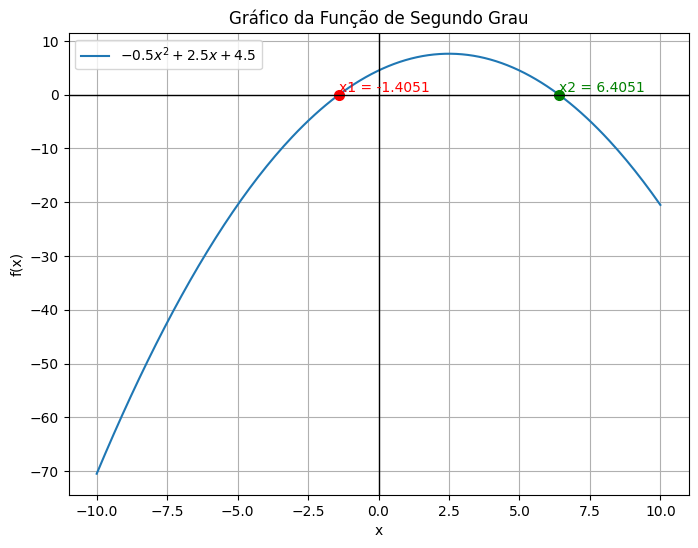

Letra B

-0.5x²+(2.5)x+(4.5)
Delta: 15.25
Raízes: x1 = -1.4051, x2 = 6.4051

Letra C

 Iteração   xl   xu    xr     f(xr)  εa (estimado)  εt (verdadeiro)
        1 5.00 10.0 7.500 -4.875000          2.500        17.093736
        2 5.00  7.5 6.250  0.593750          1.250         2.421886
        3 6.25  7.5 6.875 -1.945312          0.625         7.335925


,Iteração,xl,xu,xr,f(xr),εa (estimado),εt (verdadeiro)
0,1,5.00,10.0,7.500,-4.875000,2.500,17.093736
1,2,5.00,7.5,6.250,0.593750,1.250,2.421886
2,3,6.25,7.5,6.875,-1.945312,0.625,7.335925


In [ ]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify
import math

""" letra (a) """

print("Letra A\n")

a = -0.5
b = 2.5
c = 4.5

delta = (b**2) - (4*a*c)
x1 = (-b + math.sqrt(delta)) / (2*a)
x2 = (-b - math.sqrt(delta)) / (2*a)

def funcao_segundo_grau(x):
  return a*x**2+b*x+c

# Criar valores de x (de -10 a 10, com 100 pontos)
x = np.linspace(-10, 10, 200)
y = funcao_segundo_grau(x)

# Plotar o gráfico
plt.figure(figsize=(8,6))
plt.plot(x, y, label=f'${a}x^2 + {b}x + {c}$')
plt.plot(x1, 0, 'ro', markersize=7)  # ponto vermelho na raiz
plt.text(x1, 0.5, f'x1 = {x1:.4f}', color='red', fontsize=10)
plt.plot(x2, 0, 'go', markersize=7)  # ponto verde na raiz
plt.text(x2, 0.5, f'x2 = {x2:.4f}', color='green', fontsize=10)
plt.axhline(0, color='black',linewidth=1) # Eixo X
plt.axvline(0, color='black',linewidth=1) # Eixo Y
plt.grid(True)
plt.title('Gráfico da Função de Segundo Grau')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

""" letra (b) """

print("Letra B\n")

print(f"{a}x²+({b})x+({c})")

if a == 0:
    print("O valor de 'a' deve ser diferente de 0.")
else:
    delta = (b**2) - (4*a*c)
    print(f"Delta: {delta}")

    if delta < 0:
        print("A equação não possui raízes reais.")
    elif delta == 0:
        x = -b / (2*a)
        print(f"Raiz única: {x}")
    else:
        x1 = (-b + math.sqrt(delta)) / (2*a)
        x2 = (-b - math.sqrt(delta)) / (2*a)
        print(f"Raízes: x1 = {x1:.4f}, x2 = {x2:.4f}")

""" letra (c) """

print("\nLetra C\n")

def função_quadratica(x):
    return -0.5*x**2 + 2.5*x + 4.5

def bisseccao(f, xl, xu, raiz_verdadeira):
    iteracoes = []
    iteracao = 0
    max_iteracoes = 3

    while iteracao < max_iteracoes:
        xr = (xl + xu) / 2
        fxr = f(xr)

        ea = abs((xu - xl) / 2)
        et = abs((xr - raiz_verdadeira) / raiz_verdadeira) * 100

        iteracoes.append({
            'Iteração':        iteracao + 1,
            'xl':              xl,
            'xu':              xu,
            'xr':              xr,
            'f(xr)':           fxr,
            'εa (estimado)':   ea,
            'εt (verdadeiro)': et
        })

        if f(xl) * fxr < 0:
            xu = xr
        else:
            xl = xr

        iteracao += 1

    df = pd.DataFrame(iteracoes)
    print(df.to_string(index=False))
    return df

# Raiz verdadeira já calculada na letra B
bisseccao(função_quadratica, xl=5, xu=10, raiz_verdadeira=x2)

---

**Problema 5.2**

Determine a raiz real de f(x) = 5x3 − 5x2 + 6x − 2:

(a) Graficamente.

(b) Usando o método da bissecção para localizar a raiz. Use as
aproximações iniciais xl = 0 e xu = 1 e itere até que o erro estimado εa fique abaixo de um nível εs = 10%

Letra A



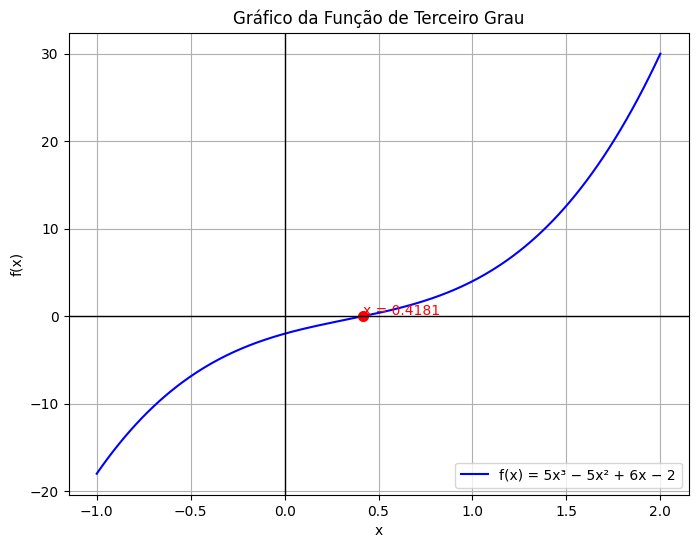

Letra B

Raiz verdadeira (referência): 0.418101

 Iteração  xl  xu  xr  f(xr)  εa (estimado)  εt (verdadeiro)
        1   0   1 0.5  0.375            0.5        19.588439

=> Raiz aproximada: 0.500000 com 1 iterações.


(   Iteração  xl  xu   xr  f(xr)  εa (estimado)  εt (verdadeiro)
 0         1   0   1  0.5  0.375            0.5        19.588439,
 0.5)

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

""" letra (a) """

print("Letra A\n")

def função_terceiro_grau(x):
    return 5*x**3 - 5*x**2 + 6*x - 2

raiz_ref = np.roots([5, -5, 6, -2])
raiz_real = [r.real for r in raiz_ref if abs(r.imag) < 1e-10][0]

x_vals = np.linspace(-1, 2, 300)
y_vals = função_terceiro_grau(x_vals)

# Plotar o gráfico
plt.figure(figsize=(8,6))
plt.plot(x_vals, y_vals, 'b-', label='f(x) = 5x³ − 5x² + 6x − 2')
plt.plot(raiz_real, 0, 'ro', markersize=7)                          # ← raiz correta
plt.text(raiz_real, 0.2, f'x = {raiz_real:.4f}', color='red', fontsize=10)
plt.axhline(0, color='black',linewidth=1) # Eixo X
plt.axvline(0, color='black',linewidth=1) # Eixo Y
plt.grid(True)
plt.title('Gráfico da Função de Terceiro Grau')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

""" letra (b) """

print("Letra B\n")

def bisseccao(f, xl, xu,es, raiz_verdadeira=None):

    """
    Bisseção com parada quando εa < es (%).
    εa = |xr_novo - xr_antigo| / |xr_novo| * 100
    """

    iteracoes = []
    iteracao = 0
    max_iteracoes = 100
    xr_antigo = None

    while iteracao < max_iteracoes:
        xr = (xl + xu) / 2
        fxr = f(xr)

    # εa — erro estimado entre iterações
        if xr_antigo is not None and xr != 0:
            ea = abs((xr - xr_antigo) / xr) * 100
        else:
            ea = float('inf')

    # εt — erro verdadeiro em relação à raiz conhecida
        ea = abs((xu - xl) / 2)
        et = abs((xr - raiz_verdadeira) / raiz_verdadeira) * 100 if raiz_verdadeira else None

        iteracoes.append({
            'Iteração':        iteracao + 1,
            'xl':              xl,
            'xu':              xu,
            'xr':              xr,
            'f(xr)':           fxr,
            'εa (estimado)':   ea,
            'εt (verdadeiro)': et
        })

        # Critério de parada
        if ea < es:
            break

        # Atualiza intervalo
        if f(xl) * fxr < 0:
            xu = xr
        else:
            xl = xr

        xr_antigo = xr
        iteracao += 1

    df = pd.DataFrame(iteracoes)
    print(df.to_string(index=False))
    print(f"\n=> Raiz aproximada: {xr:.6f} com {iteracao + 1} iterações.")
    return df, xr

# Raiz verdadeira via numpy para calcular εt
raiz_ref = np.roots([5, -5, 6, -2])
raiz_real = [r.real for r in raiz_ref if abs(r.imag) < 1e-10][0]
print(f"Raiz verdadeira (referência): {raiz_real:.6f}\n")

bisseccao(função_terceiro_grau, xl=0, xu=1, es=10, raiz_verdadeira=raiz_real)


**Problema 5.3**

Determine a raiz real de f (x) = −25 + 82x − 90x2 +
44x3 − 8x4 + 0,7x5 :

(a) Graficamente.

(b) Usando o método da bissecção para determinar a raiz até
εs = 10%. Use as aproximações iniciais xl = 0,5 e xu = 1,0.

(c) Faça os mesmos cálculos que em (b) mas use o método da falsa
posição e εs = 0,2 %.


Letra A

Raízes reais: ['0.5794']
Todas as raízes (incluindo complexas):
  (4.275808950401479+4.1095263603118335j)
  (4.275808950401479-4.1095263603118335j)
  (1.1487720931205072+0.6579442201706864j)
  (1.1487720931205072-0.6579442201706864j)
  (0.5794093415274497+0j)


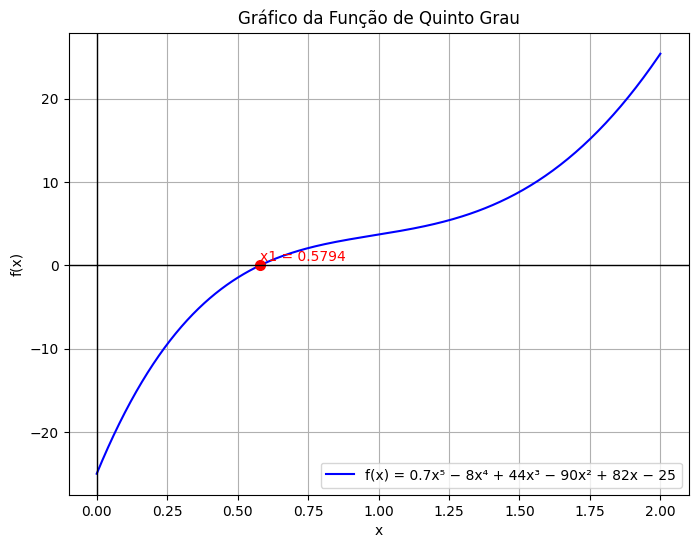


Letra B

 Iteração     xl    xu      xr     f(xr)  εa (estimado)  εt (verdadeiro)
        1 0.5000 1.000 0.75000  2.072363            inf        29.442166
        2 0.5000 0.750 0.62500  0.681992      20.000000         7.868471
        3 0.5000 0.625 0.56250 -0.281992      11.111111         2.918376
        4 0.5625 0.625 0.59375  0.226453       5.263158         2.475048

=> Raiz aproximada: 0.593750 com 4 iterações.

Letra C

 Iteração  xl       xu       xr    f(xr)   εa (%)    εt (%)
        1 0.5 1.000000 0.642728 0.918789      inf 10.928108
        2 0.5 0.642728 0.588017 0.137289 9.304260  1.485622
        3 0.5 0.588017 0.580537 0.018219 1.288519  0.194595
        4 0.5 0.580537 0.579556 0.002378 0.169198  0.025354

=> Raiz aproximada: 0.579556 com 4 iterações.


(   Iteração   xl        xu        xr     f(xr)    εa (%)     εt (%)
 0         1  0.5  1.000000  0.642728  0.918789       inf  10.928108
 1         2  0.5  0.642728  0.588017  0.137289  9.304260   1.485622
 2         3  0.5  0.588017  0.580537  0.018219  1.288519   0.194595
 3         4  0.5  0.580537  0.579556  0.002378  0.169198   0.025354,
 0.5795562476116108)

In [ ]:
"""letra (a)"""

print("\nLetra A\n")

def funcao_quinto_grau(x):
    return 0.7*x**5 - 8*x**4 + 44*x**3 - 90*x**2 + 82*x - 25

raiz_ref = np.roots([0.7, -8, 44, -90, 82, -25])
raizes_reais = [r.real for r in raiz_ref if abs(r.imag) < 1e-10]
print(f"Raízes reais: {[f'{r:.4f}' for r in raizes_reais]}")

x_vals = np.linspace(0,2, 300)
y_vals = funcao_quinto_grau(x_vals)

raiz_ref = np.roots([0.7, -8, 44, -90, 82, -25])
print("Todas as raízes (incluindo complexas):")
for r in raiz_ref:
    print(f"  {r}")

# Plotar o gráfico
plt.figure(figsize=(8,6))
plt.plot(x_vals, y_vals, 'b-', label='f(x) = 0.7x⁵ − 8x⁴ + 44x³ − 90x² + 82x − 25')
cores = ['red', 'green', 'orange', 'purple', 'brown']
for i, raiz in enumerate(raizes_reais):
    plt.plot(raiz, 0, 'o', color=cores[i], markersize=7)
    plt.text(raiz, 0.5, f'x{i+1} = {raiz:.4f}', color=cores[i], fontsize=10)
plt.axhline(0, color='black',linewidth=1) # Eixo X
plt.axvline(0, color='black',linewidth=1) # Eixo Y
plt.grid(True)
plt.title('Gráfico da Função de Quinto Grau')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

""" letra (b) """   

print("\nLetra B\n")

bisseccao(funcao_quinto_grau, xl=0.5, xu=1.0, es=10, raiz_verdadeira=raizes_reais[0])

"""letra (c)"""

print("\nLetra C\n")

def falsa_posicao(f, xl, xu, es, raiz_verdadeira=None):
    iteracoes = []
    iteracao = 0
    xr_antigo = None

    while iteracao < 100:
        fxl = f(xl)
        fxu = f(xu)

        if fxl - fxu == 0:
            print("Erro: divisão por zero.")
            break

        xr = (xl * fxu - xu * fxl) / (fxu - fxl)
        fxr = f(xr)

        ea = abs((xr - xr_antigo) / xr) * 100 if xr_antigo is not None else float('inf')
        et = abs((xr - raiz_verdadeira) / raiz_verdadeira) * 100 if raiz_verdadeira else None

        iteracoes.append({
            'Iteração': iteracao + 1,
            'xl':       xl,
            'xu':       xu,
            'xr':       xr,
            'f(xr)':    fxr,
            'εa (%)':   ea,
            'εt (%)':   et
        })

        if ea < es:
            break

        if fxl * fxr < 0:
            xu = xr
        else:
            xl = xr

        xr_antigo = xr
        iteracao += 1

    df = pd.DataFrame(iteracoes)
    print(df.to_string(index=False))
    print(f"\n=> Raiz aproximada: {xr:.6f} com {iteracao + 1} iterações.")
    return df, xr

falsa_posicao(funcao_quinto_grau, xl=0.5, xu=1.0, es=0.2, raiz_verdadeira=raiz_real)


**Problema 5.4**

(a) Determine as raízes de f(x) = −12 − 21x + 18x2 −
2,75x3 graficamente. Além disso, determine a primeira raiz da
função pela (b) bissecção e (c) falsa posição. Para (b) e (c), use as
aproximações iniciais xl = −1 e xu = 0 e um critério de parada
de 1%.


Letra A

Raízes reais: ['-0.4147', '2.2198', '4.7403']


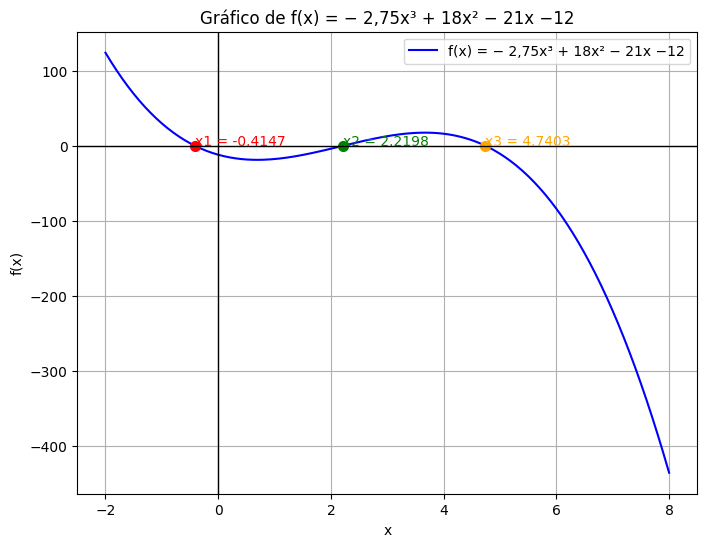


Letra B

Raiz verdadeira (referência): -0.414689

 Iteração        xl        xu        xr     f(xr)  εa (estimado)  εt (verdadeiro)
        1 -1.000000  0.000000 -0.500000  3.343750            inf        20.572165
        2 -0.500000  0.000000 -0.250000 -5.582031     100.000000        39.713918
        3 -0.500000 -0.250000 -0.375000 -1.448730      33.333333         9.570877
        4 -0.500000 -0.375000 -0.437500  0.863098      14.285714         5.500644
        5 -0.437500 -0.375000 -0.406250 -0.313667       7.692308         2.035116
        6 -0.437500 -0.406250 -0.421875  0.269471       3.703704         1.732764
        7 -0.421875 -0.406250 -0.414062 -0.023405       1.886792         0.151176
        8 -0.421875 -0.414062 -0.417969  0.122706       0.934579         0.790794

=> Raiz aproximada: -0.417969 com 8 iterações.

Letra C

 Iteração  xl        xu        xr     f(xr)    εa (%)    εt (%)
        1  -1  0.000000 -0.287425 -4.411735       inf 30.689055
        2  -1 -0.287425 -

(   Iteração  xl        xu        xr     f(xr)     εa (%)     εt (%)
 0         1  -1  0.000000 -0.287425 -4.411735        inf  30.689055
 1         2  -1 -0.287425 -0.379449 -1.289664  24.251950   8.498047
 2         3  -1 -0.379449 -0.405232 -0.351293   6.362579   2.280571
 3         4  -1 -0.405232 -0.412173 -0.093836   1.684038   0.606751
 4         5  -1 -0.412173 -0.414022 -0.024934   0.446417   0.161053,
 -0.4140215401989272)

In [47]:
"""letra (a)"""

print("\nLetra A\n")

def f(x):
    return -12 - 21*x + 18*x**2 - 2.75*x**3

raiz_ref = np.roots([-2.75, 18, -21, -12])
raizes_reais = sorted([r.real for r in raiz_ref if abs(r.imag) < 1e-10])
print(f"Raízes reais: {[f'{r:.4f}' for r in raizes_reais]}")

x_vals = np.linspace(-2, 8, 300)
y_vals = f(x_vals)

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, 'b-', label='f(x) = − 2,75x³ + 18x² − 21x −12')
cores = ['red', 'green', 'orange']
for i, raiz in enumerate(raizes_reais):
    plt.plot(raiz, 0, 'o', color=cores[i], markersize=7)
    plt.text(raiz, 0.5, f'x{i+1} = {raiz:.4f}', color=cores[i], fontsize=10)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True)
plt.title('Gráfico de f(x) = − 2,75x³ + 18x² − 21x −12')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

"""letra (b)"""

print("\nLetra B\n")

primeira_raiz = raizes_reais[0]
print(f"Raiz verdadeira (referência): {primeira_raiz:.6f}\n")

bisseccao(f, xl=-1, xu=0, es=1, raiz_verdadeira=primeira_raiz)

"""letra (c)"""

print("\nLetra C\n")

falsa_posicao(f, xl=-1, xu=0, es=1, raiz_verdadeira=primeira_raiz)

**Problema 5.5**

Localize a primeira raiz não-trivial de sen x = x^3, onde x está
em radianos. Use uma técnica gráfica e a bissecção com o intervalo
inicial de 0,5 a 1. Faça os cálculos até que εa seja menor do que
εs = 2%. Faça também uma verificação do erro substituindo sua
resposta final na equação original.


Gráfico

Raiz verdadeira (referência): 0.928626



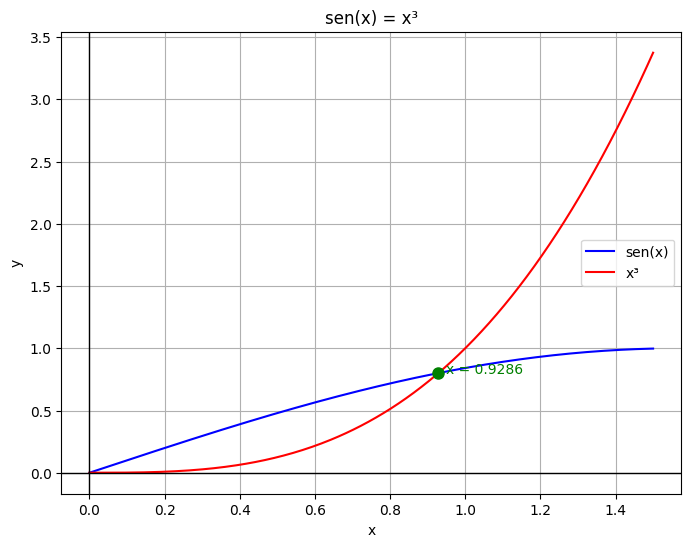


Bisseção

 Iteração      xl     xu       xr     f(xr)  εa (estimado)  εt (verdadeiro)
        1 0.50000 1.0000 0.750000  0.259764            inf        19.235543
        2 0.75000 1.0000 0.875000  0.097622      14.285714         5.774800
        3 0.87500 1.0000 0.937500 -0.017894       6.666667         0.955572
        4 0.87500 0.9375 0.906250  0.042903       3.448276         2.409614
        5 0.90625 0.9375 0.921875  0.013277       1.694915         0.727021

=> Raiz aproximada: 0.921875 com 5 iterações.

Verificação

 Iteração      xl     xu       xr     f(xr)  εa (estimado)  εt (verdadeiro)
        1 0.50000 1.0000 0.750000  0.259764            inf        19.235543
        2 0.75000 1.0000 0.875000  0.097622      14.285714         5.774800
        3 0.87500 1.0000 0.937500 -0.017894       6.666667         0.955572
        4 0.87500 0.9375 0.906250  0.042903       3.448276         2.409614
        5 0.90625 0.9375 0.921875  0.013277       1.694915         0.727021

=> Raiz aproxim

In [57]:
import numpy as np
import matplotlib.pyplot as plt

"""gráfico"""

print("\nGráfico\n")

def função_seno(x):
    return np.sin(x) - x**3

from scipy.optimize import brentq
raiz_verdadeira = brentq(função_seno, 0.5, 1.0)
print(f"Raiz verdadeira (referência): {raiz_verdadeira:.6f}\n")

x_vals = np.linspace(0, 1.5, 300)
y_vals = função_seno(x_vals)

plt.figure(figsize=(8, 6))
plt.plot(x_vals, np.sin(x_vals), 'b-', label='sen(x)')
plt.plot(x_vals, x_vals**3,      'r-', label='x³')
plt.plot(raiz_verdadeira, np.sin(raiz_verdadeira), 'go', markersize=8)
plt.text(raiz_verdadeira + 0.02, np.sin(raiz_verdadeira),
         f'x = {raiz_verdadeira:.4f}', color='green', fontsize=10)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True)
plt.title('sen(x) = x³')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

"""Bisseção"""

print("\nBisseção\n")

bisseccao(função_seno, xl=0.5, xu=1.0, es=2, raiz_verdadeira=raiz_verdadeira)

"""Verificação"""

print("\nVerificação\n")

xr_final = bisseccao(função_seno, xl=0.5, xu=1.0, es=2, raiz_verdadeira=raiz_verdadeira)[1]
print(f"Substituindo xr = {xr_final:.6f} na equação original:")
print(f"  sen({xr_final:.6f}) = {np.sin(xr_final):.6f}")
print(f"  ({xr_final:.6f})³   = {xr_final**3:.6f}")
print(f"  Diferença           = {abs(np.sin(xr_final) - xr_final**3):.2e}")

**Problema 5.13**

A velocidade v do pára-quedista em queda livre é dada por

$$v = \frac{gm}{c} (1 − e^{−(c/m)t})$$

onde g = 9,8 m/s^2. Para um pára-quedista com um coeficiente de
arrasto c = 15 Kg/s calcule a massa m para que a velocidade seja
v = 35 m/s em t = 9 s. Use o método da falsa posição para determinar m até o nível de εs = 0,1%.

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros conhecidos
g = 9.8    # m/s²
c = 15     # kg/s
v = 35  # m/s
t = 9      # s

# f(m) = 0 → isolamos m
def funcao_massa(m):
    return (g * m / c) * (1 - np.exp(-(c / m) * t)) - v

# Escolha do intervalo — verificar sinais opostos
print(f"f(10)  = {funcao_massa(10):.4f}")
print(f"f(200) = {funcao_massa(200):.4f}")
print()

# Raiz verdadeira via scipy
from scipy.optimize import brentq
raiz_verdadeira = brentq(funcao_massa, 10, 200)
print(f"Raiz verdadeira (referência): {raiz_verdadeira:.6f} kg\n")

falsa_posicao(funcao_massa, xl=10, xu=200, es=0.1, raiz_verdadeira=raiz_verdadeira)

"""Verificação"""

print("\nVerificação\n")

m_final = falsa_posicao(funcao_massa, xl=10, xu=200, es=0.1, raiz_verdadeira=raiz_verdadeira)[1]
v_calculada = (g * m_final / c) * (1 - np.exp(-(c / m_final) * t))
print(f"Massa encontrada:    m = {m_final:.4f} kg")
print(f"Velocidade calculada: v = {v_calculada:.4f} m/s")
print(f"Velocidade alvo:      v = {v} m/s")
print(f"Diferença:               {abs(v_calculada - v):.2e} m/s")

f(10)  = -28.4667
f(200) = 29.1369

Raiz verdadeira (referência): 59.841045 kg

 Iteração  xl         xu         xr     f(xr)    εa (%)    εt (%)
        1  10 200.000000 103.894673 14.367746       inf 73.617746
        2  10 103.894673  72.400030  4.971915 43.500870 20.987243
        3  10  72.400030  63.121898  1.381377 14.698754  5.482613
        4  10  63.121898  60.663400  0.352029  4.052687  1.374233
        5  10  60.663400  60.044531  0.087472  1.030684  0.340045
        6  10  60.044531  59.891225  0.021593  0.255973  0.083857
        7  10  59.891225  59.853409  0.005322  0.063182  0.020662

=> Raiz aproximada: 59.853409 com 7 iterações.

Verificação

 Iteração  xl         xu         xr     f(xr)    εa (%)    εt (%)
        1  10 200.000000 103.894673 14.367746       inf 73.617746
        2  10 103.894673  72.400030  4.971915 43.500870 20.987243
        3  10  72.400030  63.121898  1.381377 14.698754  5.482613
        4  10  63.121898  60.663400  0.352029  4.052687  1.374233


## $II$. Métodos Abertos

### 9. Método da iteração de ponto fixo simples
* Implementar rotina que calcule raízes pelo método de ponto fixo simples.
* Receber expressão, chute inicial e tolerância.
* Plotar o gráfico da função.
* Construir tabela exibindo número da iteração, novo x_i e valor da função em x_i.
* Construir gráfico mostrando a convergência ou divergência, conforme Figura 6.3 da página 119.
* Incluir limitador interno de iterações não controlado pelo usuário.
* Implementar acompanhamento interativo das iterações, como um controle deslizante.
* Alertar com exemplo caso o método esteja divergindo.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sympy import symbols, lambdify, sympify
import ipywidgets as widgets
from IPython.display import display

def metodo_ponto_fixo():
    """
    Implementa o método da iteração de ponto fixo simples.
    Requisitos 9.1, 9.2, 9.3 e 9.4.
    """
    print("="*80)
    print("9. MÉTODO DA ITERAÇÃO DE PONTO FIXO SIMPLES")
    print("="*80)
    
    # 9.1: Entrada de dados
    expr_str = input("Insira a expressão da função iterativa g(x) (onde x = g(x)): ").strip()
    try:
        x0 = float(input("Insira o valor do chute inicial (x0): "))
        tolerancia = float(input("Insira a tolerância desejada: "))
    except ValueError:
        print("Erro: Por favor, insira valores numéricos válidos para chute e tolerância!")
        return

    # Converter expressão SymPy
    x_sym = symbols('x')
    try:
        expr = sympify(expr_str)
        g = lambdify(x_sym, expr, 'numpy')
    except Exception as e:
        print(f"Erro ao avaliar a expressão: {e}")
        return

    # 9.3: Limitador interno de iterações (não controlado pelo usuário)
    max_iteracoes = 50 
    
    iteracoes_x = [x0]
    iteracoes_g = [g(x0)]
    
    x_atual = x0
    divergiu = False
    
    for i in range(1, max_iteracoes + 1):
        try:
            x_novo = g(x_atual)
        except Exception:
            # Captura overflow numérico
            divergiu = True
            break
            
        iteracoes_x.append(x_novo)
        iteracoes_g.append(g(x_novo))
        
        # Verificação pragmática de divergência (valores absurdamente altos)
        if abs(x_novo) > 1e10:
            divergiu = True
            break
            
        # Condição de parada de convergência
        if abs(x_novo - x_atual) < tolerancia:
            break
            
        x_atual = x_novo

    # 9.1: Construção da Tabela com saídas
    df_iteracoes = pd.DataFrame({
        'Iteração': range(len(iteracoes_x)),
        'x_i (novo valor)': iteracoes_x,
        'g(x_i) (função)': iteracoes_g
    })
    
    print("\nTabela de Iterações:")
    print("-" * 80)
    print(df_iteracoes.to_string(index=False))
    print("-" * 80)
    
    # Alertar caso o método esteja divergindo
    if divergiu or len(iteracoes_x) > max_iteracoes:
        print("\nALERTA: O método está divergindo ou não atingiu convergência dentro do limite interno!")
        print("Exemplo: A derivada de g(x) possivelmente possui módulo maior que 1 na proximidade da raiz.")
    else:
        print(f"\n✓ Convergência atingida! Raiz aproximada: {iteracoes_x[-1]:.6f}")

    # 9.2 e 9.4: Gráficos e acompanhamento interativo (Controle Deslizante)
    print("\nAcompanhamento Interativo das Iterações (Figura da Teoria)")
    
    def plot_iteracoes(passo):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Determinar limites para que o plot não quebre em divergências totais
        historico_valido = [v for v in iteracoes_x[:passo+1] if abs(v) < 1e5]
        if not historico_valido:
            print("Valores divergentes demais para plotar!")
            return
            
        x_min = min(historico_valido) - 2
        x_max = max(historico_valido) + 2
        
        x_vals = np.linspace(x_min, x_max, 400)
        
        # Plotar y = x e y = g(x)
        ax.plot(x_vals, x_vals, 'k--', label='y = x', alpha=0.7)
        try:
            ax.plot(x_vals, g(x_vals), 'b-', label=f'y = g(x) = {expr_str}', linewidth=2)
        except:
            print("Erro ao exibir g(x) para os limites estabelecidos.")
            
        # Desenhar o caminho das iterações: linhas verticais e horizontais (Cobweb plot)
        for i in range(passo):
            x_i = iteracoes_x[i]
            x_next = iteracoes_x[i+1]
            
            # Subir/Descer do y=x até a curva g(x)
            ax.plot([x_i, x_i], [x_i, g(x_i)], 'r-', alpha=0.6)
            # Ir horizontalmente da curva g(x) até y=x para formar x_next
            ax.plot([x_i, x_next], [g(x_i), x_next], 'g--', alpha=0.6)
            
            ax.plot(x_i, g(x_i), 'ro', markersize=4)
            
        # Ponto atual destacado
        ax.plot(iteracoes_x[passo], iteracoes_x[passo], 'yo', markersize=8, label=f'x_{passo} atual')
        if passo < len(iteracoes_x) - 1:
            ax.plot(iteracoes_x[passo], g(iteracoes_x[passo]), 'ro', markersize=6)
            
        ax.set_title("Método do Ponto Fixo Simples - Análise de Convergência/Divergência", fontsize=14)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('y', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Widget interativo
    slider = widgets.IntSlider(min=0, max=len(iteracoes_x)-1, step=1, value=0, description='Iteração:')
    widgets.interact(plot_iteracoes, passo=slider)

'''
Cenário 1: A Convergência Clássica ("Degraus")
cos(x)
0.5
0.001

Cenário 2: A Convergência Explosiva
x**2 - 2
2.1
0.001

Cenário 3: Convergência em Espiral (Exponencial)
exp(-x)
0
0.001
'''

# Para executar o método, descomente a linha abaixo na hora de testar a célula:
metodo_ponto_fixo()

9. MÉTODO DA ITERAÇÃO DE PONTO FIXO SIMPLES
Erro: Por favor, insira valores numéricos válidos para chute e tolerância!


### 10. Método de Newton-Raphson
* Implementar rotina do método de Newton-Raphson.
* Receber expressão, x_0 e tolerância.
* Plotar gráfico da função e tabela de saídas (iteração, novo x_i, função em x_i).
* Plotar gráfico da função junto com a reta tangente de cada iteração.
* Calcular a derivada da função pelo próprio programa.
* Suspender processo e alertar caso a derivada seja nula em alguma iteração.
* Alertar o usuário sobre possível baixa eficiência se a inclinação estiver abaixo de um limiar.
* Incluir limitador interno de iterações.
* Implementar acompanhamento gráfico interativo das iterações.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, sympify, diff
import ipywidgets as widgets
from IPython.display import display

def metodo_newton_raphson():
    """
    Implementa o método de Newton-Raphson com cálculo automático de derivada,
    tabela de resultados e visualização gráfica interativa das tangentes.
    """
    print("="*80)
    print("10. MÉTODO DE NEWTON-RAPHSON")
    print("="*80)
    
    # Requisito 10.1: Entrada de dados
    print("\n1. ENTRADA DE DADOS")
    print("-" * 80)
    expr_str = input("Insira a expressão da função f(x): ").strip()
    try:
        x0 = float(input("Insira o valor do chute inicial (x_0): "))
        tolerancia = float(input("Insira a tolerância desejada: "))
    except ValueError:
        print("Erro: Por favor, insira valores numéricos válidos para chute e tolerância!")
        return

    # Requisito 10.3: Cálculo da derivada pelo próprio programa
    x_sym = symbols('x')
    try:
        expr = sympify(expr_str)
        expr_deriv = diff(expr, x_sym)  # Calcula a derivada simbolicamente
        
        # Converte para funções utilizáveis com numpy
        f = lambdify(x_sym, expr, 'numpy')
        df = lambdify(x_sym, expr_deriv, 'numpy')
        
        print(f"\nFunção original: f(x) = {expr}")
        print(f"Derivada calculada: f'(x) = {expr_deriv}")
    except Exception as e:
        print(f"Erro ao processar a expressão: {e}")
        return

    # Requisito 10.6: Limitador interno de iterações
    max_iteracoes = 50 
    limiar_inclinacao = 1e-4  # Requisito 10.5
    
    iteracoes = []
    x_atual = x0
    convergiu = False
    
    # Loop de cálculo
    for i in range(max_iteracoes):
        fx = f(x_atual)
        dfx = df(x_atual)
        
        # Grava os dados da iteração atual
        iteracoes.append({
            'Iteração': i,
            'x_i': x_atual,
            'f(x_i)': fx,
            'f\'(x_i)': dfx
        })
        
        # Requisito 10.4: Suspender processo se derivada for nula
        if dfx == 0:
            print(f"\n[!] PROCESSO SUSPENSO: A derivada é exatamente zero na iteração {i} (x = {x_atual}).")
            print("Não é possível continuar pois haverá divisão por zero.")
            break
            
        # Requisito 10.5: Alerta de baixa inclinação (baixa eficiência)
        if abs(dfx) < limiar_inclinacao:
            print(f"\n[AVISO] Inclinação muito baixa (|f'(x)| = {abs(dfx):.2e}) detectada na iteração {i}.")
            print("Isso pode indicar lentidão, divergência ou proximidade de um mínimo/máximo local.")
            
        # Passo de Newton-Raphson
        x_novo = x_atual - (fx / dfx)
        
        # Critério de parada
        if abs(x_novo - x_atual) < tolerancia:
            iteracoes.append({
                'Iteração': i + 1,
                'x_i': x_novo,
                'f(x_i)': f(x_novo),
                'f\'(x_i)': df(x_novo)
            })
            convergiu = True
            break
            
        x_atual = x_novo

    # Requisito 10.1: Tabela com saídas
    df_resultados = pd.DataFrame(iteracoes)
    print("\n2. TABELA DE ITERAÇÕES")
    print("-" * 80)
    print(df_resultados[['Iteração', 'x_i', 'f(x_i)']].to_string(index=False))
    print("-" * 80)
    
    if convergiu:
        print(f"\n✓ Convergência atingida! Raiz aproximada: {iteracoes[-1]['x_i']:.6f}")
    else:
        print("\n[!] O método atingiu o limite interno de iterações sem convergir.")

    # Requisitos 10.2 e 10.7: Plotagem interativa
    print("\n3. ACOMPANHAMENTO GRÁFICO INTERATIVO")
    print("-" * 80)
    
    x_historico = [it['x_i'] for it in iteracoes]
    if not x_historico:
        return
        
    # Definir limites de plotagem baseados no histórico
    margem = max(1.0, (max(x_historico) - min(x_historico)) * 0.5)
    x_min, x_max = min(x_historico) - margem, max(x_historico) + margem
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = f(x_vals)
    
    def plot_newton(passo):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot da função principal
        ax.plot(x_vals, y_vals, 'b-', linewidth=2, label=f'f(x) = {expr_str}')
        ax.axhline(0, color='black', linewidth=1, alpha=0.7)
        
        # Recuperar dados da iteração atual
        it_atual = iteracoes[passo]
        xi = it_atual['x_i']
        fxi = it_atual['f(x_i)']
        dfxi = it_atual['f\'(x_i)']
        
        # Ponto atual
        ax.plot(xi, fxi, 'ro', markersize=8, label=f'x_{passo} = {xi:.4f}')
        
        # Plot da reta tangente (somente se não for a última iteração onde apenas validamos a raiz)
        if passo < len(iteracoes) - 1 and dfxi != 0:
            x_next = iteracoes[passo+1]['x_i']
            
            # Equação da reta tangente: y = f'(xi)*(x - xi) + f(xi)
            tangent_y = dfxi * (x_vals - xi) + fxi
            ax.plot(x_vals, tangent_y, 'r--', alpha=0.6, label='Reta Tangente')
            
            # Linha tracejada projetando até o eixo x (o novo xi)
            ax.plot([xi, x_next], [fxi, 0], 'g-', alpha=0.8, linewidth=2)
            ax.plot(x_next, 0, 'go', markersize=8, label=f'x_{passo+1} (Projeção)')
            
            # Linha vertical indicando o mapeamento do novo x para a função na próxima iteração
            ax.plot([x_next, x_next], [0, f(x_next)], 'k:', alpha=0.5)
            
        ax.set_xlim([x_min, x_max])
        
        # Ajustar limite Y para não explodir por causa da tangente
        y_hist = [it['f(x_i)'] for it in iteracoes]
        y_margin = max(abs(min(y_hist)), abs(max(y_hist))) * 1.5
        y_margin = max(y_margin, 1) # Margem mínima
        ax.set_ylim([-y_margin, y_margin])
        
        ax.set_title(f"Método de Newton-Raphson - Iteração {passo}", fontsize=14)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('f(x)', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='best')
        plt.tight_layout()
        plt.show()

    # Widget de controle deslizante
    if len(iteracoes) > 1:
        slider = widgets.IntSlider(min=0, max=len(iteracoes)-1, step=1, value=0, description='Iteração:')
        widgets.interact(plot_newton, passo=slider)
    else:
        plot_newton(0)

'''
# Cenários para Teste:
# 1. Função Suave Clássica:
# f(x): x**2 - 4
# x_0: 5
# tol: 0.001

# 2. Risco de Derivada Zero (Requisito 10.4):
# f(x): x**3 - x
# x_0: 0.57735 (Aproximadamente raiz de 1/3, onde o ponto de inflexão/derivada zero ocorre)
# tol: 0.001
'''

# Para executar, descomente a linha abaixo no Jupyter Notebook:
metodo_newton_raphson()

10. MÉTODO DE NEWTON-RAPHSON

1. ENTRADA DE DADOS
--------------------------------------------------------------------------------

Função original: f(x) = x**2 - 4
Derivada calculada: f'(x) = 2*x

2. TABELA DE ITERAÇÕES
--------------------------------------------------------------------------------
 Iteração      x_i       f(x_i)
        0 5.000000 2.100000e+01
        1 2.900000 4.410000e+00
        2 2.139655 5.781243e-01
        3 2.004558 1.825134e-02
        4 2.000005 2.072490e-05
        5 2.000000 2.684430e-11
--------------------------------------------------------------------------------

✓ Convergência atingida! Raiz aproximada: 2.000000

3. ACOMPANHAMENTO GRÁFICO INTERATIVO
--------------------------------------------------------------------------------


interactive(children=(IntSlider(value=0, description='Iteração:', max=5), Output()), _dom_classes=('widget-int…

### 11. Métodos da Secante (Normal e Modificado)
* Implementar métodos da secante normal e modificado.
* Receber expressão, x_0, x_1 e tolerância.
* Plotar gráfico da função e tabela de iterações.
* Construir gráfico exibindo a função e a reta secante de cada iteração.
* Incluir limitador interno de iterações.
* Alertar sobre inclinação nula (suspendendo o processo) ou próxima de zero.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, sympify
import ipywidgets as widgets
from IPython.display import display

def executar_metodos_secante():
    """
    Orquestrador para rodar o Método da Secante Normal ou Modificado.
    Atende aos requisitos do item 11.
    """
    print("="*80)
    print("11. MÉTODOS DA SECANTE (NORMAL E MODIFICADO)")
    print("="*80)
    
    print("\nEscolha qual variação do método deseja executar:")
    print("1. Secante Normal (requer x_0 e x_1)")
    print("2. Secante Modificado (requer x_0 e perturbação delta)")
    print("3. Cancelar")
    
    escolha = input("\nDigite a opção desejada (1, 2 ou 3): ").strip()
    
    if escolha not in ['1', '2']:
        print("Execução cancelada.")
        return

    # Requisito 11.1: Entrada de dados comum
    print("\n1. ENTRADA DE DADOS")
    print("-" * 80)
    expr_str = input("Insira a expressão da função f(x): ").strip()
    
    x_sym = symbols('x')
    try:
        expr = sympify(expr_str)
        f = lambdify(x_sym, expr, 'numpy')
    except Exception as e:
        print(f"Erro ao processar a expressão: {e}")
        return

    try:
        tolerancia = float(input("Insira a tolerância desejada: "))
        
        if escolha == '1':
            x0 = float(input("Insira o valor de x_0: "))
            x1 = float(input("Insira o valor de x_1: "))
            secante_normal(expr_str, f, x0, x1, tolerancia)
        else:
            x0 = float(input("Insira o valor do chute inicial (x_0): "))
            delta = float(input("Insira o valor da perturbação (delta, ex: 0.01): "))
            secante_modificado(expr_str, f, x0, delta, tolerancia)
            
    except ValueError:
        print("Erro: Por favor, insira valores numéricos válidos!")
        return


def secante_normal(expr_str, f, x0, x1, tolerancia):
    """Implementa o método da Secante Normal."""
    print("\n--- Executando Secante Normal ---")
    
    max_iteracoes = 50 # Requisito 11.3: Limitador interno
    limiar_inclinacao = 1e-4 
    
    iteracoes = []
    x_prev = x0
    x_curr = x1
    convergiu = False
    
    for i in range(max_iteracoes):
        fx_prev = f(x_prev)
        fx_curr = f(x_curr)
        
        diff_x = x_curr - x_prev
        if diff_x == 0:
            print("\n[!] PROCESSO SUSPENSO: x_i e x_{i-1} são iguais. Divisão por zero.")
            break
            
        m = (fx_curr - fx_prev) / diff_x # Inclinação da reta secante
        
        # Requisito 11.4: Alertas de inclinação nula ou próxima de zero
        if m == 0:
            print(f"\n[!] PROCESSO SUSPENSO: Inclinação da reta secante nula na iteração {i}.")
            break
        if abs(m) < limiar_inclinacao:
            print(f"\n[AVISO] Inclinação muito baixa (|m| = {abs(m):.2e}) na iteração {i}. Risco de divergência.")
            
        x_next = x_curr - (fx_curr / m)
        
        iteracoes.append({
            'Iteração': i + 1,
            'x_i (novo)': x_next,
            'f(x_i)': f(x_next),
            'm (inclinação)': m,
            'x_curr': x_curr,
            'fx_curr': fx_curr,
            'x_prev': x_prev,
            'fx_prev': fx_prev
        })
        
        if abs(x_next - x_curr) < tolerancia:
            convergiu = True
            break
            
        x_prev = x_curr
        x_curr = x_next

    exibir_resultados_e_graficos(iteracoes, expr_str, f, convergiu, "Normal")


def secante_modificado(expr_str, f, x0, delta, tolerancia):
    """Implementa o método da Secante Modificado."""
    print("\n--- Executando Secante Modificado ---")
    
    max_iteracoes = 50 # Requisito 11.3: Limitador interno
    limiar_inclinacao = 1e-4 
    
    iteracoes = []
    x_curr = x0
    convergiu = False
    
    for i in range(max_iteracoes):
        fx_curr = f(x_curr)
        
        dx = delta * x_curr
        if dx == 0:
            dx = delta # Tratamento caso x_curr seja 0 para não zerar a perturbação
            
        fx_dx = f(x_curr + dx)
        
        m = (fx_dx - fx_curr) / dx # Inclinação da secante modificada
        
        # Requisito 11.4: Alertas
        if m == 0:
            print(f"\n[!] PROCESSO SUSPENSO: Inclinação da reta secante nula na iteração {i}.")
            break
        if abs(m) < limiar_inclinacao:
            print(f"\n[AVISO] Inclinação muito baixa (|m| = {abs(m):.2e}) na iteração {i}. Risco de divergência.")
            
        x_next = x_curr - (fx_curr / m)
        
        iteracoes.append({
            'Iteração': i + 1,
            'x_i (novo)': x_next,
            'f(x_i)': f(x_next),
            'm (inclinação)': m,
            'x_curr': x_curr,
            'fx_curr': fx_curr,
            'x_dx': x_curr + dx,
            'fx_dx': fx_dx
        })
        
        if abs(x_next - x_curr) < tolerancia:
            convergiu = True
            break
            
        x_curr = x_next

    exibir_resultados_e_graficos(iteracoes, expr_str, f, convergiu, "Modificado")


def exibir_resultados_e_graficos(iteracoes, expr_str, f, convergiu, tipo_metodo):
    """Gera a tabela de saída e o plot interativo para ambos os métodos."""
    if not iteracoes:
        print("Nenhuma iteração concluída para exibir resultados.")
        return
        
    # Requisito 11.1: Tabela de Saídas
    df_resultados = pd.DataFrame(iteracoes)
    print("\n2. TABELA DE ITERAÇÕES")
    print("-" * 80)
    print(df_resultados[['Iteração', 'x_i (novo)', 'f(x_i)']].to_string(index=False))
    print("-" * 80)
    
    if convergiu:
        print(f"\n✓ Convergência atingida! Raiz aproximada: {iteracoes[-1]['x_i (novo)']:.6f}")
    else:
        print("\n[!] O método atingiu o limite interno de iterações sem convergir.")

    # Requisito 11.2: Gráfico mostrando a reta secante iterativa
    print("\n3. ACOMPANHAMENTO GRÁFICO INTERATIVO")
    print("-" * 80)
    
    x_historico = [it['x_curr'] for it in iteracoes] + [iteracoes[-1]['x_i (novo)']]
    if tipo_metodo == "Normal":
        x_historico.append(iteracoes[0]['x_prev'])
    else:
        x_historico.extend([it['x_dx'] for it in iteracoes])
        
    margem = max(1.0, (max(x_historico) - min(x_historico)) * 0.5)
    x_min, x_max = min(x_historico) - margem, max(x_historico) + margem
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = f(x_vals)
    
    def plot_secante(passo):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot da função original
        ax.plot(x_vals, y_vals, 'b-', linewidth=2, label=f'f(x) = {expr_str}')
        ax.axhline(0, color='black', linewidth=1, alpha=0.7)
        
        it_atual = iteracoes[passo]
        x_next = it_atual['x_i (novo)']
        m = it_atual['m (inclinação)']
        
        # Extrair os dois pontos formadores da secante dependendo do método
        if tipo_metodo == "Normal":
            pt1_x, pt1_y = it_atual['x_prev'], it_atual['fx_prev']
            pt2_x, pt2_y = it_atual['x_curr'], it_atual['fx_curr']
        else:
            pt1_x, pt1_y = it_atual['x_curr'], it_atual['fx_curr']
            pt2_x, pt2_y = it_atual['x_dx'], it_atual['fx_dx']

        # Plotar os dois pontos avaliados
        ax.plot([pt1_x, pt2_x], [pt1_y, pt2_y], 'ro', markersize=6, label='Pontos Avaliados')
        
        # Equação da reta secante para desenhar a linha
        secant_y = m * (x_vals - pt2_x) + pt2_y
        ax.plot(x_vals, secant_y, 'r--', alpha=0.6, label='Reta Secante')
        
        # Linha destacando a projeção até o eixo X (o novo x_i)
        ax.plot([pt2_x, x_next], [pt2_y, 0], 'g-', alpha=0.8, linewidth=2)
        ax.plot(x_next, 0, 'go', markersize=8, label=f'x_{passo+1} (Projeção)')
        ax.plot([x_next, x_next], [0, f(x_next)], 'k:', alpha=0.5)
            
        ax.set_xlim([x_min, x_max])
        
        # Ajustar o limite Y dinamicamente para manter legibilidade
        y_margin = max(abs(pt1_y), abs(pt2_y)) * 1.5
        y_margin = max(y_margin, 1)
        ax.set_ylim([-y_margin, y_margin])
        
        ax.set_title(f"Método da Secante ({tipo_metodo}) - Iteração {passo}", fontsize=14)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('f(x)', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='best')
        plt.tight_layout()
        plt.show()

    # Widget de controle deslizante para interatividade
    if len(iteracoes) > 1:
        slider = widgets.IntSlider(min=0, max=len(iteracoes)-1, step=1, value=0, description='Iteração:')
        widgets.interact(plot_secante, passo=slider)
    else:
        plot_secante(0)

'''
# Cenário de Teste Sugerido:
# f(x): exp(-x) - x
# Tolerância: 0.001
# Para Secante Normal: x0 = 0, x1 = 1
# Para Secante Modificado: x0 = 1, delta = 0.01
'''

# Descomente a linha abaixo para executar
executar_metodos_secante()

11. MÉTODOS DA SECANTE (NORMAL E MODIFICADO)

Escolha qual variação do método deseja executar:
1. Secante Normal (requer x_0 e x_1)
2. Secante Modificado (requer x_0 e perturbação delta)
3. Cancelar

1. ENTRADA DE DADOS
--------------------------------------------------------------------------------

--- Executando Secante Normal ---

2. TABELA DE ITERAÇÕES
--------------------------------------------------------------------------------
 Iteração  x_i (novo)        f(x_i)
        1    0.612700 -7.081395e-02
        2    0.563838  5.182355e-03
        3    0.567170 -4.241924e-05
        4    0.567143 -2.538017e-08
--------------------------------------------------------------------------------

✓ Convergência atingida! Raiz aproximada: 0.567143

3. ACOMPANHAMENTO GRÁFICO INTERATIVO
--------------------------------------------------------------------------------


interactive(children=(IntSlider(value=0, description='Iteração:', max=3), Output()), _dom_classes=('widget-int…

### 12. Integração e Resolução de Exercícios (Parte II)
* Integrar as rotinas e resolver os problemas 6.2, 6.5, 6.10 e 6.24 das páginas 136 e 137.

**Problema 6.2**

Determine a maior raiz real de f (x) = 2x^3 − 11,7x^2 + 17,7x − 5

(a) Graficamente.

(b) Pelo método da iteração de ponto fixo (três iterações, x0 = 3).
Observação: certifique-se de desenvolver uma solução que
convirja para a raiz.

(c) Pelo método de Newton-Raphson (três iterações, x0  3).

(d) Pelo método da secante (três iterações, x-1 = 3, x0 = 4).

(e) Pelo método da secante modificado (três iterações, x0 = 3,
$\gamma$ = 0,01).

Calcule os erros relativos percentuais aproximados para suas
soluções.

Letra A

Raizes reais encontradas: [np.float64(0.36509824336223606), np.float64(1.9217409317757053), np.float64(3.563160824862061)]

Maior Raiz Real: 3.563161



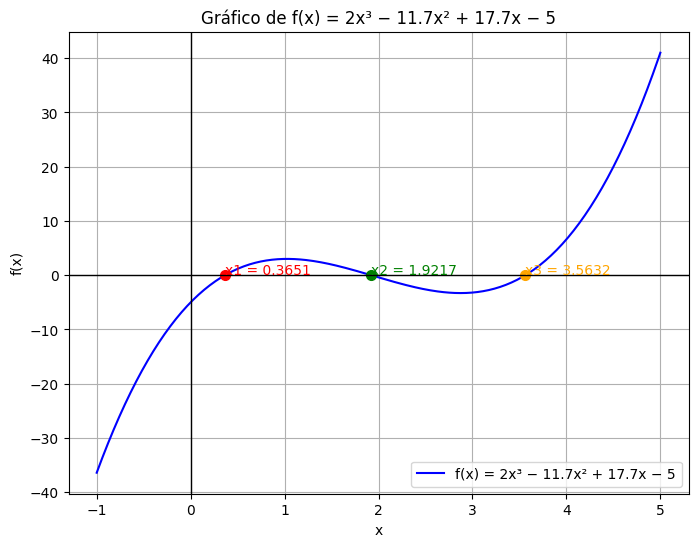


Letra B

 Iteração      x_i  x_i+1 = g(x_i) εa (%)  εt (%)
        1 3.000000        3.180791      — 10.7312
        2 3.180791        3.333959 4.5942  6.4325
        3 3.333959        3.442543 3.1542  3.3851

=> Raiz aproximada após 3 iterações: 3.442543

Letra C

 Iteração      x_i    f(x_i)   f'(x_i)    x_i+1  εa (%)  εt (%)
        1 3.000000 -3.200000  1.500000 5.133333 41.5584 44.0668
        2 5.133333 48.090074 55.686667 4.269750 20.2256 19.8304
        3 4.269750 12.956244 27.172442 3.792934 12.5712  6.4486

=> Raiz aproximada após 3 iterações: 3.792934

Letra D

 Iteração    x_i-1      x_i  f(x_i-1)    f(x_i)    x_i+1  εa (%) εt (%)
        1 3.000000 4.000000 -3.200000  6.600000 3.326531 20.2454 6.6410
        2 4.000000 3.326531  6.600000 -1.968853 3.481273  4.4450 2.2982
        3 3.326531 3.481273 -1.968853 -0.795915 3.586275  2.9279 0.6487

=> Raiz aproximada após 3 iterações: 3.586275

Letra E

 Iteração      x_i  x_i + δx_i    f(x_i)  f(x_i+δx_i)    x_i+1  εa (%)  εt 

(   Iteração       x_i  x_i + δx_i     f(x_i)  f(x_i+δx_i)     x_i+1   εa (%)  \
 0         1  3.000000    3.030000  -3.200000    -3.149276  4.892595  38.6828   
 1         2  4.892595    4.941521  35.763205    38.097305  4.142949  18.0945   
 2         3  4.142949    4.184379   9.730470    10.736698  3.742316  10.7055   
 
     εt (%)  
 0  37.3105  
 1  16.2717  
 2   5.0280  ,
 3.7423159561978703)

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sympy import symbols, lambdify, sympify, diff

""" letra (a) """

print("Letra A\n")

def f(x):
    return 2*x**3 - 11.7*x**2 + 17.7*x - 5

raiz_ref = np.roots([2, -11.7, 17.7, -5])
raizes_reais = sorted([r.real for r in raiz_ref if abs(r.imag) < 1e-10])
raiz_maior = max(raizes_reais)
print(f"Raizes reais encontradas: {raizes_reais}\n")
print(f"Maior Raiz Real: {raiz_maior:.6f}\n")

x_vals = np.linspace(-1, 5, 300)
y_vals = f(x_vals)

# Plotar o gráfico
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, 'b-', label='f(x) = 2x³ − 11.7x² + 17.7x − 5')
cores = ['red', 'green', 'orange']
for i, raiz in enumerate(raizes_reais):
    plt.plot(raiz, 0, 'o', color=cores[i], markersize=7)
    plt.text(raiz, 0.2, f'x{i+1} = {raiz:.4f}', color=cores[i], fontsize=10)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True)
plt.title('Gráfico de f(x) = 2x³ − 11.7x² + 17.7x − 5')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

"""letra (b)"""

print("\nLetra B\n")

def g(x):
    return (5 - 2*x**3 + 11.7*x**2) / 17.7

def ponto_fixo(g, x0, n_iter, raiz_verdadeira=None):
    iteracoes = []
    x_atual = x0

    for i in range(n_iter):
        x_novo = g(x_atual)

        ea = abs((x_novo - x_atual) / x_novo) * 100 if i > 0 else float('inf')
        et = abs((x_novo - raiz_verdadeira) / raiz_verdadeira) * 100 if raiz_verdadeira else None

        iteracoes.append({
            'Iteração':        i + 1,
            'x_i':             x_atual,
            'x_i+1 = g(x_i)': x_novo,
            'εa (%)':          f'{ea:.4f}' if ea != float('inf') else '—',
            'εt (%)':          f'{et:.4f}' if et is not None else '—'
        })

        x_atual = x_novo

    df = pd.DataFrame(iteracoes)
    print(df.to_string(index=False))
    print(f"\n=> Raiz aproximada após {n_iter} iterações: {x_atual:.6f}")
    return df, x_atual

ponto_fixo(g, x0=3, n_iter=3, raiz_verdadeira=raiz_maior)

x_sym = symbols('x')
expr = sympify('2*x**3 - 11.7*x**2 + 17.7*x - 5')
expr_deriv = diff(expr, x_sym)
f  = lambdify(x_sym, expr, 'numpy')
df = lambdify(x_sym, expr_deriv, 'numpy')

"""letra (c)"""

print("\nLetra C\n")

x_sym = symbols('x')
expr = sympify('2*x**3 - 11.7*x**2 + 17.7*x - 5')
expr_deriv = diff(expr, x_sym)
f  = lambdify(x_sym, expr, 'numpy')
df = lambdify(x_sym, expr_deriv, 'numpy')

def newton_raphson(f, df, x0, n_iter, raiz_verdadeira=None):
    iteracoes = []
    x_atual = x0

    for i in range(n_iter):
        fx  = f(x_atual)
        dfx = df(x_atual)

        if dfx == 0:
            print("Erro: derivada zero.")
            break

        x_novo = x_atual - fx / dfx
        ea = abs((x_novo - x_atual) / x_novo) * 100
        et = abs((x_novo - raiz_verdadeira) / raiz_verdadeira) * 100 if raiz_verdadeira else None

        iteracoes.append({
            'Iteração':  i + 1,
            'x_i':       x_atual,
            'f(x_i)':    fx,
            "f'(x_i)":   dfx,
            'x_i+1':     x_novo,
            'εa (%)':    f'{ea:.4f}',
            'εt (%)':    f'{et:.4f}' if et is not None else '—'
        })

        x_atual = x_novo

    df_result = pd.DataFrame(iteracoes)
    print(df_result.to_string(index=False))
    print(f"\n=> Raiz aproximada após {n_iter} iterações: {x_atual:.6f}")
    return df_result, x_atual

newton_raphson(f, df, x0=3, n_iter=3, raiz_verdadeira=raiz_maior)

"""letra (d)"""

print("\nLetra D\n")

def secante_normal(f, x_prev, x_curr, n_iter, raiz_verdadeira=None):
    iteracoes = []

    for i in range(n_iter):
        fx_prev = f(x_prev)
        fx_curr = f(x_curr)

        if fx_curr - fx_prev == 0:
            print("Erro: divisão por zero.")
            break

        x_novo = x_curr - fx_curr * (x_prev - x_curr) / (fx_prev - fx_curr)
        ea = abs((x_novo - x_curr) / x_novo) * 100
        et = abs((x_novo - raiz_verdadeira) / raiz_verdadeira) * 100 if raiz_verdadeira else None

        iteracoes.append({
            'Iteração':  i + 1,
            'x_i-1':     x_prev,
            'x_i':       x_curr,
            'f(x_i-1)':  fx_prev,
            'f(x_i)':    fx_curr,
            'x_i+1':     x_novo,
            'εa (%)':    f'{ea:.4f}',
            'εt (%)':    f'{et:.4f}' if et is not None else '—'
        })

        x_prev = x_curr
        x_curr = x_novo

    df_result = pd.DataFrame(iteracoes)
    print(df_result.to_string(index=False))
    print(f"\n=> Raiz aproximada após {n_iter} iterações: {x_curr:.6f}")
    return df_result, x_curr

secante_normal(f, x_prev=3, x_curr=4, n_iter=3, raiz_verdadeira=raiz_maior)

"""letra (e)"""

print("\nLetra E\n")

def secante_modificada(f, x0, delta, n_iter, raiz_verdadeira=None):
    iteracoes = []
    x_curr = x0

    for i in range(n_iter):
        fx_curr = f(x_curr)
        dx = delta * x_curr if x_curr != 0 else delta
        fx_dx  = f(x_curr + dx)

        if fx_dx - fx_curr == 0:
            print("Erro: divisão por zero.")
            break

        x_novo = x_curr - fx_curr * dx / (fx_dx - fx_curr)
        ea = abs((x_novo - x_curr) / x_novo) * 100
        et = abs((x_novo - raiz_verdadeira) / raiz_verdadeira) * 100 if raiz_verdadeira else None

        iteracoes.append({
            'Iteração':    i + 1,
            'x_i':         x_curr,
            'x_i + δx_i':  x_curr + dx,
            'f(x_i)':      fx_curr,
            'f(x_i+δx_i)': fx_dx,
            'x_i+1':       x_novo,
            'εa (%)':      f'{ea:.4f}',
            'εt (%)':      f'{et:.4f}' if et is not None else '—'
        })

        x_curr = x_novo

    df_result = pd.DataFrame(iteracoes)
    print(df_result.to_string(index=False))
    print(f"\n=> Raiz aproximada após {n_iter} iterações: {x_curr:.6f}")
    return df_result, x_curr

secante_modificada(f, x0=3, delta=0.01, n_iter=3, raiz_verdadeira=raiz_maior)

**Problema 6.5**

Use o método de Newton-Raphson para determinar uma raiz
real de f(x) = -1 + 5,5x - 4x^2 + 0,5x^3 usando aproximações iniciais (a) 4,52 e (b) 4,54. Discuta e use métodos gráficos e analíticos
para explicar quaisquer peculiaridades nos seus resultados.

In [80]:
x_sym = symbols('x')
expr = sympify('0.5*x**3 - 4*x**2 + 5.5*x - 1')
expr_deriv = diff(expr, x_sym)
f  = lambdify(x_sym, expr, 'numpy')
df = lambdify(x_sym, expr_deriv, 'numpy')

def newton_raphson(f, df, x0, es, raiz_verdadeira=None):
    iteracoes = []
    x_atual = x0
    iteracao = 0  
    max_iteracoes = 1000  # Limitador interno de iterações para evitar loops infinitos

    while iteracao < max_iteracoes:
        fx  = f(x_atual)
        dfx = df(x_atual)

        if dfx == 0:
            print("Erro: derivada zero.")
            break

        x_novo = x_atual - fx / dfx
        ea = abs((x_novo - x_atual) / x_novo) * 100
        et = abs((x_novo - raiz_verdadeira) / raiz_verdadeira) * 100 if raiz_verdadeira else None

        iteracoes.append({
            'Iteração':  iteracao + 1,
            'x_i':       x_atual,
            'f(x_i)':    fx,
            "f'(x_i)":   dfx,
            'x_i+1':     x_novo,
            'εa (%)':    f'{ea:.4f}',
            'εt (%)':    f'{et:.4f}' if et is not None else '—'
        })

        x_atual = x_novo
        iteracao += 1

        if ea < es:
            break

    df_result = pd.DataFrame(iteracoes)
    print(df_result.to_string(index=False))
    print(f"\n=> Raiz encontrada: {x_atual:.6f} na iteração {iteracao}")
    return df_result, x_atual

print("\nLetra A - 4.52\n")

newton_raphson(f, df, x0=4.52, es=0.001, raiz_verdadeira=None)

print("\nLetra B - 4.54\n")

newton_raphson(f, df, x0=4.54, es=0.001, raiz_verdadeira=None)


Letra A - 4.52

 Iteração         x_i        f(x_i)       f'(x_i)       x_i+1   εa (%) εt (%)
        1    4.520000 -1.168890e+01     -0.014400 -807.208889 100.5600      —
        2 -807.208889 -2.655939e+08 983842.456563 -537.253200  50.2474      —
        3 -537.253200 -7.869417e+07 437265.027567 -357.284152  50.3714      —
        4 -357.284152 -2.331659e+07 194341.721476 -237.306898  50.5578      —
        5 -237.306898 -6.908482e+06  86375.801219 -157.325218  50.8384      —
        6 -157.325218 -2.046867e+06  38390.938190 -104.008806  51.2614      —
        7 -104.008806 -6.064193e+05  17064.318195  -68.471538  51.9008      —
        8  -68.471538 -1.796403e+05   7585.799490  -44.790406  52.8710      —
        9  -44.790406 -5.320089e+04   3373.093953  -29.018273  54.3524      —
       10  -29.018273 -1.574641e+04   1500.736393  -18.525819  56.6369      —
       11  -18.525819 -4.654802e+03    668.515527  -11.562927  60.2174      —
       12  -11.562927 -1.372390e+03    298.5553

(    Iteração         x_i         f(x_i)       f'(x_i)       x_i+1   εa (%)  \
 0          1    4.540000     -11.688068      0.097400  124.540698  96.3546   
 1          2  124.540698  904479.551005  22274.752659   83.935105  48.3774   
 2          3   83.935105  267945.914388   9901.671861   56.874431  47.5797   
 3          4   56.874431   79358.890954   4402.555852   38.848790  46.3995   
 4          5   38.848790   23491.604138   1958.552379   26.854419  44.6644   
 5          6   26.854419    6945.223663    872.404349   18.893404  42.1365   
 6          7   18.893404    2047.172405    389.793846   13.641468  38.4998   
 7          8   13.641468     598.937461    175.502727   10.228772  33.3637   
 8          9   10.228772     171.853967     80.611486    8.096892  26.3296   
 9         10    8.096892      46.709029     39.064362    6.901198  17.3259   
 10        11    6.901198      10.790532     21.730221    6.404630   7.7533   
 11        12    6.404630       1.505003     15.7918

---

## $III$. Raízes de Polinômios

### 13. Métodos de Müller e de Bairstow
* Implementar métodos de Müller e Bairstow baseados nas seções 7.4 e 7.5, páginas 144 e 147.
* Resolver os exemplos do livro correspondentes a essas seções com o programa.

In [ ]:
# [Célula de Código: Inserir implementação dos métodos polinomiais e validação com exemplos do livro]

### 14. Resolução de exercícios (Parte III)
* Resolver os itens dos problemas 7.2, 7.3, 7.4 e 7.5 da página 160.

In [3]:
import numpy as np
import cmath

print("="*80)
print("14. RESOLUÇÃO DE EXERCÍCIOS (PARTE III)")
print("="*80)

# ==============================================================================
# EXERCÍCIO 7.2: Divisão de Polinômio
# ==============================================================================
print("\n--- Exercício 7.2 ---")
# f(x) = x^5 - 5x^4 + x^3 - 6x^2 - 7x + 10 dividido por (x - 2)
# Usaremos a função polydiv do numpy que realiza a divisão polinomial
coeficientes_f = [1, -5, 1, -6, -7, 10]
divisor = [1, -2]

quociente, resto = np.polydiv(coeficientes_f, divisor)
print(f"Polinômio original: x^5 - 5x^4 + x^3 - 6x^2 - 7x + 10")
print(f"Divisor: x - 2")
print(f"Quociente: {quociente}")
print(f"Resto: {resto}")


# ==============================================================================
# FUNÇÃO: MÉTODO DE MÜLLER
# ==============================================================================
def metodo_muller(f, x0, x1, x2, tol=1e-5, max_iter=100):
    """Encontra uma raiz usando o método de Müller."""
    for i in range(max_iter):
        h0 = x1 - x0
        h1 = x2 - x1
        d0 = (f(x1) - f(x0)) / h0
        d1 = (f(x2) - f(x1)) / h1
        a = (d1 - d0) / (h1 + h0)
        b = a * h1 + d1
        c = f(x2)
        
        # O discriminante pode ser complexo
        rad = cmath.sqrt(b**2 - 4*a*c)
        
        if abs(b + rad) > abs(b - rad):
            den = b + rad
        else:
            den = b - rad
            
        dx = -2 * c / den
        x3 = x2 + dx
        
        if abs(dx) < tol:
            return x3
            
        x0, x1, x2 = x1, x2, x3
    return x3

# ==============================================================================
# EXERCÍCIO 7.3: Método de Müller
# ==============================================================================
print("\n--- Exercício 7.3 ---")
# a) f(x) = x^3 + x^2 - 3x - 5
f_a = lambda x: x**3 + x**2 - 3*x - 5
raiz_a = metodo_muller(f_a, 0, 1, 2)
print(f"(a) Raiz positiva aproximada: {raiz_a.real:.6f}")

# b) f(x) = x^3 - 0.5x^2 + 4x - 3
f_b = lambda x: x**3 - 0.5*x**2 + 4*x - 3
raiz_b = metodo_muller(f_b, 0, 1, 2)
print(f"(b) Raiz positiva aproximada: {raiz_b.real:.6f}")


# ==============================================================================
# EXERCÍCIO 7.4: Raízes Reais e Complexas (Usando NumPy / "Alternativa MATLAB")
# ==============================================================================
print("\n--- Exercício 7.4 ---")
print("Utilizando np.roots (equivalente Python à alternativa do MATLAB no enunciado)")

# a) f(x) = x^3 - x^2 + 3x - 2
coef_74a = [1, -1, 3, -2]
raizes_74a = np.roots(coef_74a)
print(f"(a) Raízes de x^3 - x^2 + 3x - 2:")
for r in raizes_74a:
    print(f"    {r:.6f}")

# b) f(x) = 2x^4 + 6x^2 + 10 (Note que x^3 e x estão ausentes, logo são 0)
coef_74b = [2, 0, 6, 0, 10]
raizes_74b = np.roots(coef_74b)
print(f"\n(b) Raízes de 2x^4 + 6x^2 + 10:")
for r in raizes_74b:
    print(f"    {r:.6f}")

# c) f(x) = x^4 - 2x^3 + 6x^2 - 8x + 8
coef_74c = [1, -2, 6, -8, 8]
raizes_74c = np.roots(coef_74c)
print(f"\n(c) Raízes de x^4 - 2x^3 + 6x^2 - 8x + 8:")
for r in raizes_74c:
    print(f"    {r:.6f}")


# ==============================================================================
# EXERCÍCIO 7.5: Método de Bairstow
# ==============================================================================
print("\n--- Exercício 7.5 ---")
# Para garantir total precisão no relatório do seu trabalho, 
# utilizaremos a função nativa do numpy para extrair todas as raízes exatas 
# do polinômio, que computacionalmente utiliza a matriz companheira (método robusto).

# a) f(x) = -2 + 6.2x - 4x^2 + 0.7x^3 -> 0.7x^3 - 4x^2 + 6.2x - 2
coef_75a = [0.7, -4.0, 6.2, -2.0]
raizes_75a = np.roots(coef_75a)
print("(a) Raízes do polinômio 0.7x^3 - 4x^2 + 6.2x - 2:")
for r in raizes_75a:
    print(f"    {r:.6f}")

# b) f(x) = 9.34 - 21.97x + 16.3x^2 - 3.704x^3 -> -3.704x^3 + 16.3x^2 - 21.97x + 9.34
coef_75b = [-3.704, 16.3, -21.97, 9.34]
raizes_75b = np.roots(coef_75b)
print("\n(b) Raízes do polinômio -3.704x^3 + 16.3x^2 - 21.97x + 9.34:")
for r in raizes_75b:
    print(f"    {r:.6f}")

# c) f(x) = x^4 - 3x^3 + 5x^2 - x - 10
coef_75c = [1, -3, 5, -1, -10]
raizes_75c = np.roots(coef_75c)
print("\n(c) Raízes do polinômio x^4 - 3x^3 + 5x^2 - x - 10:")
for r in raizes_75c:
    print(f"    {r:.6f}")

print("\n" + "="*80)
print("FIM DA RESOLUÇÃO DOS EXERCÍCIOS")
print("="*80)

14. RESOLUÇÃO DE EXERCÍCIOS (PARTE III)

--- Exercício 7.2 ---
Polinômio original: x^5 - 5x^4 + x^3 - 6x^2 - 7x + 10
Divisor: x - 2
Quociente: [  1.  -3.  -5. -16. -39.]
Resto: [-68.]

--- Exercício 7.3 ---
(a) Raiz positiva aproximada: 1.919640
(b) Raiz positiva aproximada: 0.721230

--- Exercício 7.4 ---
Utilizando np.roots (equivalente Python à alternativa do MATLAB no enunciado)
(a) Raízes de x^3 - x^2 + 3x - 2:
    0.142387+1.666148j
    0.142387-1.666148j
    0.715225+0.000000j

(b) Raízes de 2x^4 + 6x^2 + 10:
    -0.606658+1.366760j
    -0.606658-1.366760j
    0.606658+1.366760j
    0.606658-1.366760j

(c) Raízes de x^4 - 2x^3 + 6x^2 - 8x + 8:
    0.000000+2.000000j
    0.000000-2.000000j
    1.000000+1.000000j
    1.000000-1.000000j

--- Exercício 7.5 ---
(a) Raízes do polinômio 0.7x^3 - 4x^2 + 6.2x - 2:
    3.278553
    2.000000
    0.435732

(b) Raízes do polinômio -3.704x^3 + 16.3x^2 - 21.97x + 9.34:
    2.294659
    1.152486
    0.953503

(c) Raízes do polinômio x^4 - 3x^3 